# Ketone-body metabolism across brain cell types, disease and the *C4b*⁺ oligodendrocyte state

The two main notebooks treat ketone bodies as two pathway scores among twelve. This notebook takes the ketone arm apart gene by gene, in every
annotated cell type, across the in-house datasets (Xenium EAE, Visium aging, Falcão sorted cells) and the sixteen public datasets. Xenium AD has no
ketone gene on its panel and is skipped.

**Biology in one paragraph.** Ketone bodies (acetoacetate, β-hydroxybutyrate) are made from fatty-acid-derived acetyl-CoA by *Hmgcs2* (rate-limiting),
*Hmgcl* and *Bdh1*; in the brain this ketogenic capacity sits in astrocytes, which oxidise fatty acids (*Cpt1a*, *Acadm*, *Hadha*) and are driven by
PPARα. They are used by *Bdh1* (BHB → acetoacetate), *Oxct1* (SCOT, the committed ketolytic step, absent from liver) and *Acat1*, and they cross
membranes through the monocarboxylate transporters MCT1 (*Slc16a1*, oligodendrocytes and endothelium), MCT2 (*Slc16a7*, neurons), MCT4 (*Slc16a3*,
astrocytes), MCT7 (*Slc16a6*) and SMCT1 (*Slc5a8*). BHB also signals: it is the ligand of *Hcar2* (GPR109A) on myeloid cells and an antagonist of the
SCFA receptor *Ffar3*. Acetate is activated by *Acss1* / *Acss2*.

Questions:

1. **Who makes, who uses, who transports and who senses ketone bodies?** Detection and mean expression of every ketone gene by cell type, plus the
   fraction of cells that co-detect *Oxct1* and *Bdh1* (complete ketolytic machinery).
2. **How does that change with disease, age, demyelination and lesion distance, in every cell type?** Pseudobulk per sample, gene-wise and as
   ketogenesis / ketolysis / fatty-acid-supply scores.
3. **Is astrocyte ketogenesis coupled to fatty-acid oxidation and PPARα?** Correlation of *Hmgcs2* with *Cpt1a*, *Acadm*, *Ppara* inside astrocytes.
4. **What does the disease-associated oligodendrocyte do with ketones?** *Bdh1*, *Oxct1*, *Acat1*, *Slc16a1* in DA vs homeostatic oligodendrocytes (in situ,
   sorted), and the ketone genes' correlation with *C4b*.
5. **Human MS / AD** by lesion type and Braak stage.

Gene set: `oligometab.KETONE` (26 genes in six groups); scores: `oligometab.KETONE_SCORE_SETS`. Pathway scores are `scanpy.tl.score_genes` values compared by
difference; genes are compared by log2 fold change of pseudobulk means; Mann–Whitney across samples when both groups have ≥3 samples.

In [1]:
import os, sys, gc, traceback, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../scripts")
try:
    from dotenv import load_dotenv
    load_dotenv("../../.env")
except Exception:
    pass
import numpy as np, pandas as pd, scipy.sparse as sp, h5py, scanpy as sc, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
import oligometab as om
from oligometab import KETONE, KETONE_GENES, KETONE_SCORE_SETS, heat, short

sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, frameon=False)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 300)

GROUP_OF = {g: k for k, gs in KETONE.items() for g in gs}
KG = KETONE_GENES
CORE = ["Hmgcs2", "Hmgcl", "Bdh1", "Bdh2", "Oxct1", "Acat1", "Acss1", "Acss2", "Slc16a1", "Slc16a7", "Slc16a3", "Slc5a8", "Hcar2", "Ffar3", "Cpt1a", "Acadm", "Ppara", "Fgf21"]
CTS_TEST = [c for c in om.COARSE_TYPES if c != "Other"]

PATHS_INHOUSE = {
    "Xenium EAE":    om.resolve_path("OLIGOMETAB_XENIUM_EAE_H5AD",   "../../data/RREAE_5k_raw_only_integration_processed.h5ad"),
    "Visium aging":  om.resolve_path("OLIGOMETAB_VISIUM_AGING_H5AD", "../../data/visum_aging_brain.h5ad"),
    "Falcão EAE sc": om.resolve_path("OLIGOMETAB_FALCAO_H5AD",       "../../data/falcao_et_al_2018.h5ad"),
}
PATHS_PUBLIC = om.processed_paths()
only = os.getenv("OLIGOMETAB_ONLY_DATASETS")
if only:
    PATHS_PUBLIC = {k: v for k, v in PATHS_PUBLIC.items() if k in only.split(",")}
for k, v in PATHS_INHOUSE.items():
    print(f"{k:13s} -> {v if v else 'NOT FOUND (section will be skipped)'}")
print(len(PATHS_PUBLIC), "public datasets")
display(pd.DataFrame([(k, ", ".join(v)) for k, v in KETONE.items()], columns=["group", "genes"]).set_index("group"))
os.makedirs("../../results", exist_ok=True)
results = {}


def codetect(adata, groupby, a="Oxct1", b="Bdh1", min_cells=30):
    """Fraction of cells per group detecting a, b, and both (complete ketolytic machinery when a=Oxct1, b=Bdh1)."""
    df = om.expr_df(adata, [a, b])
    if a not in df.columns or b not in df.columns:
        return pd.DataFrame()
    g = adata.obs[groupby].astype(str).values
    rows = []
    for grp, sub in df.groupby(g):
        if len(sub) < min_cells:
            continue
        pa, pb = (sub[a] > 0).mean(), (sub[b] > 0).mean()
        both = ((sub[a] > 0) & (sub[b] > 0)).mean()
        rows.append({"group": grp, "n_cells": len(sub), f"{a}+": pa, f"{b}+": pb, "both": both, "both_expected_if_independent": pa * pb})
    return pd.DataFrame(rows).set_index("group")


def astro_coupling(adata, mask, genes=("Cpt1a", "Acadm", "Hadha", "Ppara", "Bdh1", "Hmgcl", "Slc16a3", "Gfap")):
    """Inside astrocytes: Spearman correlation of Hmgcs2 with FA-oxidation / regulator genes and detection in Hmgcs2+ vs Hmgcs2- cells."""
    sub = adata[mask]
    if sub.n_obs < 100 or om.resolve(sub, ["Hmgcs2"])["Hmgcs2"] is None or (om.expr(sub, "Hmgcs2") > 0).sum() < 20:
        return pd.DataFrame()
    return om.coexpression_with_anchor(sub, "Hmgcs2", list(genes), min_pos=20)


def gene_heat(df, title, cbar, fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, annot=None, row_labels=None):
    cols = [g for g in CORE if g in df.columns]
    heat(df[cols], title, cbar, fmt=fmt, cmap=cmap, center=center, vmin=vmin, vmax=vmax, annot=annot, row_labels=row_labels)

Xenium EAE    -> /Volumes/jamboree/RRMap/data/RREAE_5k_raw_only_integration_processed.h5ad
Visium aging  -> /Users/christoffer/work/karolinska/development/OligoC4b_complement_run/data/visum_aging_brain.h5ad
Falcão EAE sc -> /Users/christoffer/work/karolinska/development/OligoC4b/data/falcao_et_al_2018.h5ad
16 public datasets


,genes
group,
Synthesis (ketogenesis),"Hmgcs2, Hmgcl, Hmgcll1, Bdh1, Bdh2"
Utilisation (ketolysis),"Oxct1, Acat1, Bdh1"
Acetate activation,"Acss1, Acss2"
Ketone / lactate transport,"Slc16a1, Slc16a7, Slc16a3, Slc16a6, Slc5a8, Bsg"
Receptors,"Hcar2, Ffar3, Ffar2"
Fatty-acid supply / regulators,"Cpt1a, Cpt2, Acadm, Hadha, Acaa2, Ppara, Pparg..."


---
## 1. Xenium mouse EAE (5K panel)

Panel content limits this section: of the 26 ketone genes the 5K panel carries *Bdh1*, *Acss1*, *Acss2*, *Slc16a1*, *Slc16a3*, *Hcar2*, *Ffar2*, *Ffar3*,
*Cpt1a*, *Cpt2*, *Hadha*, *Acaa2*, *Ppara*, *Ppargc1a*. No *Hmgcs2*, *Hmgcl*, *Oxct1*, *Acat1*, *Slc16a7*. The matrix is raw counts and is normalised here.

In [2]:
ds = "Xenium EAE"
ad_eae = None
if PATHS_INHOUSE[ds]:
    from anndata import AnnData
    from anndata.experimental import read_elem
    with h5py.File(PATHS_INHOUSE[ds], "r") as f:
        obs = read_elem(f["obs"]); var = read_elem(f["var"])
        shape = tuple(f["X"].attrs["shape"])
        X = sp.csr_matrix((f["X/data"][:].astype(np.float32), f["X/indices"][:], f["X/indptr"][:]), shape=shape)
        spatial = f["obsm/spatial"][:]
    obs.index = obs.index.astype(str); var.index = var.index.astype(str)
    ad_eae = AnnData(X=X, obs=obs, var=var); ad_eae.obsm["spatial"] = spatial; ad_eae.obs_names_make_unique(); del X, obs, var
    ad_eae.obs["cell_type"] = ad_eae.obs["cell_type"].astype(str).replace({"DA oligodendrocytes": "DA Oligodendrocytes", "Astrocyte": "Astrocytes"})
    sc.pp.normalize_total(ad_eae, target_sum=1e4); sc.pp.log1p(ad_eae)
    kg_eae = om.present(ad_eae, KG)
    print(ad_eae.shape, "| ketone genes present:", kg_eae, "| missing:", om.missing(ad_eae, KG))
    results[ds] = {}
else:
    print("skipped")

(891821, 5101) | ketone genes present: ['Bdh1', 'Acss1', 'Acss2', 'Slc16a1', 'Slc16a3', 'Hcar2', 'Ffar3', 'Ffar2', 'Cpt1a', 'Cpt2', 'Acaa2', 'Ppara', 'Ppargc1a', 'Fgf21'] | missing: ['Hmgcs2', 'Hmgcl', 'Hmgcll1', 'Bdh2', 'Oxct1', 'Acat1', 'Slc16a7', 'Slc16a6', 'Slc5a8', 'Bsg', 'Acadm', 'Hadha']


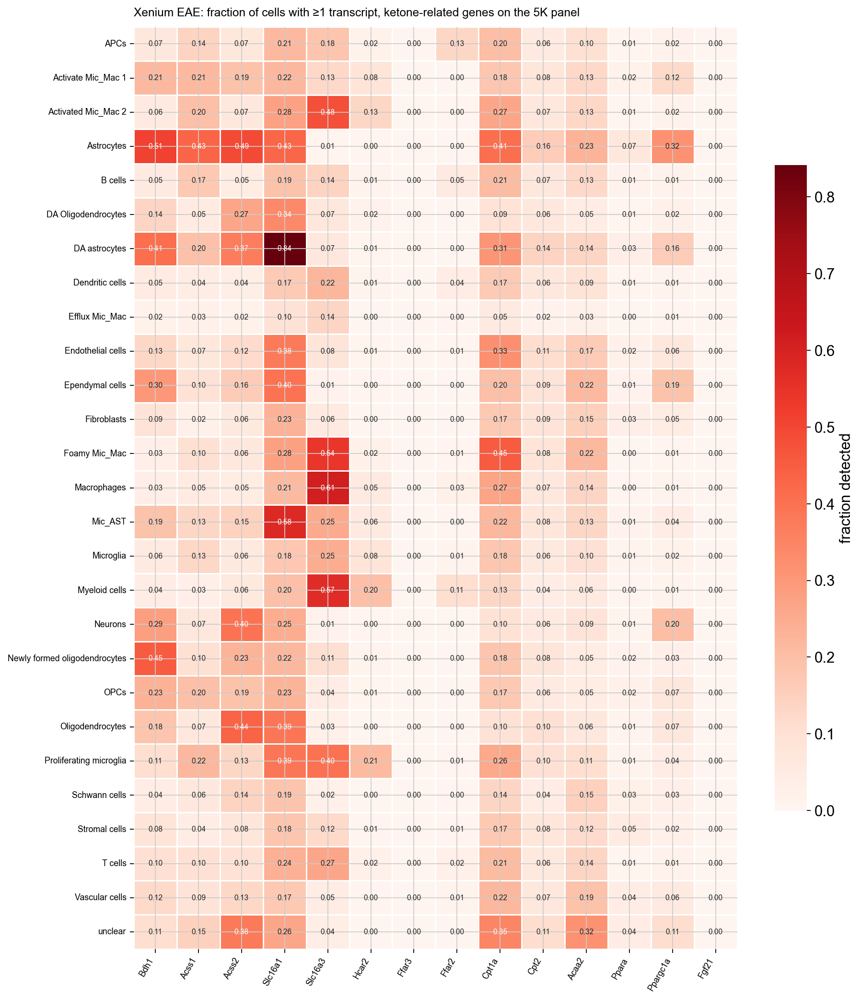

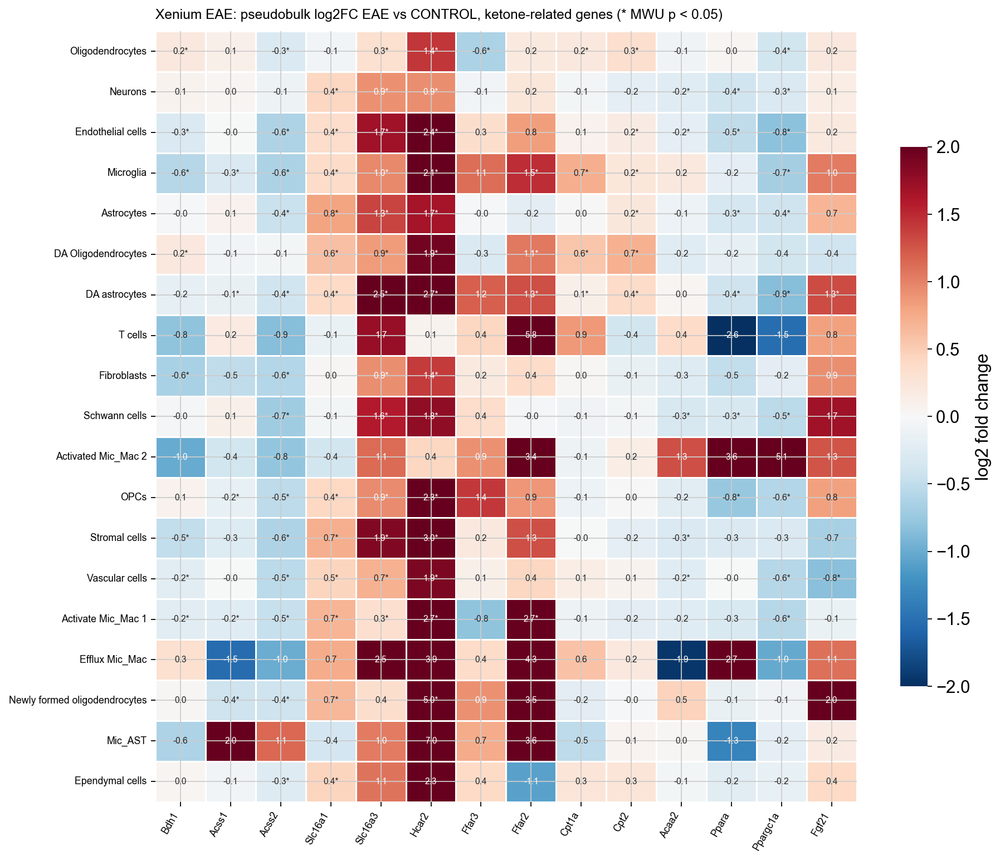

DA vs homeostatic oligodendrocytes (paired per sample):


,mean_DA_oligo,mean_homeostatic_oligo,log2FC,n_samples,wilcoxon_p
gene,,,,,
Bdh1,0.3211,0.4300,-0.4200,107,0.0000
Acss1,0.1193,0.1462,-0.2912,107,0.0000
Acss2,0.7050,1.1356,-0.6870,107,0.0000
Slc16a1,0.8302,0.9591,-0.2081,107,0.0000
Slc16a3,0.1486,0.0628,1.2301,107,0.0000
Hcar2,0.0329,0.0072,2.0577,107,0.0000
Ffar3,0.0009,0.0011,-0.1286,107,0.0431
Ffar2,0.0075,0.0041,0.7503,107,0.0010
Cpt1a,0.2058,0.2189,-0.0888,107,0.0055


DA vs homeostatic astrocytes (paired per sample):


,mean_DA_astro,mean_astro,log2FC,n_samples,wilcoxon_p
gene,,,,,
Bdh1,0.9856,1.2455,-0.3373,107,0.0000
Acss1,0.4342,1.0245,-1.2365,107,0.0000
Acss2,0.9067,1.2027,-0.4073,107,0.0000
Slc16a1,2.7254,1.1596,1.2321,107,0.0000
Slc16a3,0.1315,0.0221,2.5164,107,0.0000
Hcar2,0.0146,0.0081,0.7791,107,0.0000
Ffar3,0.0011,0.0006,0.3967,107,0.0859
Ffar2,0.0065,0.0024,1.1612,107,0.0000
Cpt1a,0.6870,0.9548,-0.4741,107,0.0000


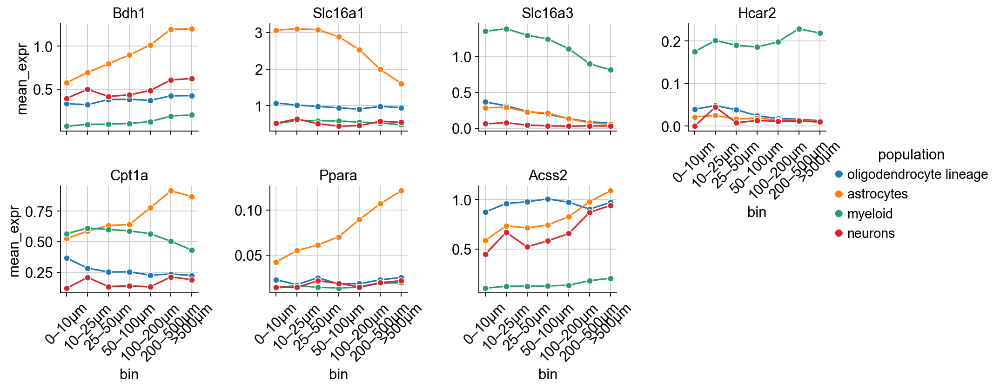

ketone genes vs C4b in DA oligodendrocytes:


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Bdh1,0.0686,0.1517,2.2123,0.0297,0.0000
Acss1,0.0270,0.0549,2.0340,-0.0132,0.0000
Acss2,0.1517,0.2933,1.9332,0.0307,0.0000
Slc16a1,0.1926,0.3748,1.9459,0.0424,0.0000
Slc16a3,0.0359,0.0774,2.1534,-0.0329,0.0000
Hcar2,0.0058,0.0176,3.0032,-0.0251,0.0000
Ffar3,0.0001,0.0004,4.0690,-0.0035,0.2281
Ffar2,0.0026,0.0030,1.1269,-0.0093,0.6651
Cpt1a,0.0463,0.1052,2.2716,0.0071,0.0000


In [3]:
if ad_eae is not None:
    vc = ad_eae.obs["cell_type"].value_counts(); cts = [c for c in vc.index if vc[c] >= 1500 and c != "unclear"]
    det = om.detection_table(ad_eae, kg_eae, "cell_type", min_cells=1500); results[ds]["detection_by_celltype"] = det
    heat(det[[g for g in kg_eae]], "Xenium EAE: fraction of cells with ≥1 transcript, ketone-related genes on the 5K panel", "fraction detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(det.index))
    mt = om.mean_table(ad_eae, kg_eae, "cell_type", min_cells=1500); results[ds]["mean_by_celltype"] = mt
    # EAE vs control per cell type, and DA vs homeostatic oligodendrocytes / DA vs homeostatic astrocytes
    sub = ad_eae[ad_eae.obs["cell_type"].isin(cts)]
    n = sub.obs.groupby(["sample_name", "cell_type"], observed=True).size().rename("n_cells").reset_index(); n[["sample_name", "cell_type"]] = n[["sample_name", "cell_type"]].astype(str)
    pb = om.pseudobulk(sub, kg_eae, "sample_name", ["cell_type", "condition"]).merge(n, on=["sample_name", "cell_type"]).query("n_cells >= 20")
    rows = []
    for ct in cts:
        p_ct = pb[pb.cell_type == ct]
        for g in kg_eae:
            ma, mr, p, na, nr = om.group_test(p_ct, g, "condition", "EAE", "CONTROL")
            rows.append({"cell_type": ct, "gene": g, "mean_EAE": ma, "mean_CONTROL": mr, "log2FC": om.log2fc(ma, mr), "MWU_p": p, "n_EAE": na, "n_CONTROL": nr})
    de = pd.DataFrame(rows); results[ds]["EAE_vs_control"] = de
    d = de.pivot(index="cell_type", columns="gene", values="log2FC").loc[cts, kg_eae]; d = d[d.notna().any(axis=1)]
    p = de.pivot(index="cell_type", columns="gene", values="MWU_p").loc[d.index, kg_eae]
    heat(d, "Xenium EAE: pseudobulk log2FC EAE vs CONTROL, ketone-related genes (* MWU p < 0.05)", "log2 fold change", fmt=".1f", cmap="RdBu_r", center=0, vmin=-2, vmax=2,
         annot=(d.round(1).astype(str) + np.where(p.values < 0.05, "*", "")).values, row_labels=list(d.index))
    # paired within sample: DA vs homeostatic oligodendrocytes, DA vs homeostatic astrocytes
    def paired_genes(mask_a, mask_b, la, lb, min_cells=20):
        df = om.expr_df(ad_eae, kg_eae); smp = ad_eae.obs["sample_name"].astype(str).values
        A, B = [], []
        for s_ in np.unique(smp):
            m = smp == s_
            if (m & mask_a).sum() >= min_cells and (m & mask_b).sum() >= min_cells:
                A.append(df[m & mask_a].mean()); B.append(df[m & mask_b].mean())
        A, B = pd.DataFrame(A), pd.DataFrame(B)
        return pd.DataFrame([{"gene": g, f"mean_{la}": A[g].mean(), f"mean_{lb}": B[g].mean(), "log2FC": om.log2fc(A[g].mean(), B[g].mean()), "n_samples": len(A),
                              "wilcoxon_p": stats.wilcoxon(A[g], B[g]).pvalue if len(A) >= 3 and not np.allclose(A[g], B[g]) else np.nan} for g in df.columns]).set_index("gene")
    ct_ = ad_eae.obs["cell_type"].values
    t1 = paired_genes(ct_ == "DA Oligodendrocytes", ct_ == "Oligodendrocytes", "DA_oligo", "homeostatic_oligo"); results[ds]["DA_vs_homeostatic_oligo"] = t1
    t2 = paired_genes(ct_ == "DA astrocytes", ct_ == "Astrocytes", "DA_astro", "astro"); results[ds]["DA_vs_homeostatic_astro"] = t2
    print("DA vs homeostatic oligodendrocytes (paired per sample):"); display(t1.round(4))
    print("DA vs homeostatic astrocytes (paired per sample):"); display(t2.round(4))
    # lesion distance
    m_eae = ((ad_eae.obs["condition"] == "EAE") & ad_eae.obs["lesion_distance_bin"].notna()).values
    import re
    bins = sorted(ad_eae.obs.loc[m_eae, "lesion_distance_bin"].astype(str).unique(), key=lambda b: (1, 0) if b.startswith(">") else (0, int(re.search(r"(\d+)", b).group(1))))
    ld_rows = []
    for label, cts_ in [("oligodendrocyte lineage", ["Oligodendrocytes", "DA Oligodendrocytes"]), ("astrocytes", ["Astrocytes", "DA astrocytes"]),
                        ("myeloid", ["Microglia", "Macrophages", "Foamy Mic_Mac", "Activate Mic_Mac 1", "Activated Mic_Mac 2", "Efflux Mic_Mac", "Myeloid cells", "Proliferating microglia"]), ("neurons", ["Neurons"])]:
        s_ = ad_eae[m_eae & ad_eae.obs["cell_type"].isin(cts_).values]
        mt_ = om.mean_table(s_, [g for g in ["Bdh1", "Slc16a1", "Slc16a3", "Hcar2", "Cpt1a", "Ppara", "Acss2"] if g in kg_eae], "lesion_distance_bin", min_cells=50).reindex(bins)
        mt_["population"] = label; ld_rows.append(mt_.reset_index().rename(columns={"index": "bin"})); del s_
    ld = pd.concat(ld_rows); results[ds]["lesion_distance"] = ld
    tidy = ld.melt(id_vars=["bin", "population"], var_name="gene", value_name="mean_expr")
    g = sns.relplot(data=tidy, x="bin", y="mean_expr", hue="population", col="gene", col_wrap=4, kind="line", marker="o", height=2.4, aspect=1.2, facet_kws={"sharey": False})
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    g.set_titles("{col_name}"); plt.show()
    # C4b co-expression with the ketone genes in DA oligodendrocytes
    dao = ad_eae[ad_eae.obs["cell_type"] == "DA Oligodendrocytes"].copy()
    co = om.coexpression_with_anchor(dao, "C4b", kg_eae); results[ds]["C4b_coexpr_DAoligo"] = co
    print("ketone genes vs C4b in DA oligodendrocytes:"); display(co[["frac_in_C4b-", "frac_in_C4b+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(4))
    del dao, sub
    for k, v in results[ds].items():
        v.to_csv(f"../../results/ketone_xenium_eae_{k}.csv")
    del ad_eae; gc.collect()

---
## 2. Visium aging mouse brain (whole transcriptome)

(16743, 32285) | missing: []


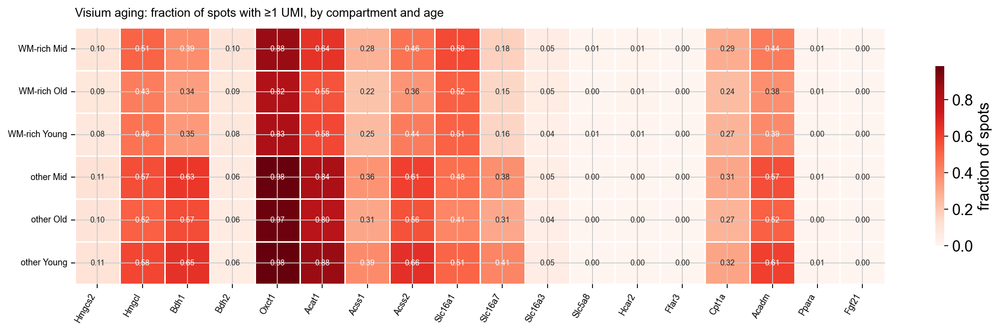

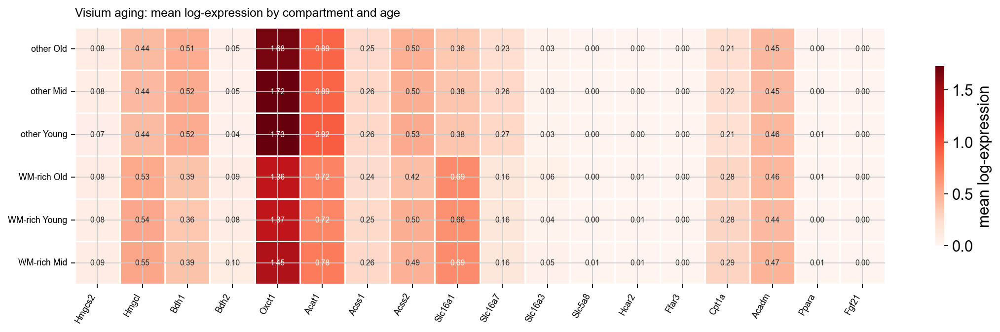

age trends (linear fit over 6 sections):


,spots,feature,kind,pearson_r,p,mean_Young,mean_Old,log2FC_old_vs_young
0,all spots,Hmgcs2,gene,0.7728,0.0715,0.0745,0.0834,0.1600
1,all spots,Hmgcl,gene,0.0786,0.8823,0.4624,0.4615,-0.0026
2,all spots,Hmgcll1,gene,-0.7866,0.0635,0.2192,0.1981,-0.1457
3,all spots,Bdh1,gene,0.2416,0.6446,0.4753,0.4805,0.0157
4,all spots,Bdh2,gene,0.5481,0.2602,0.0523,0.0608,0.2127
5,all spots,Oxct1,gene,-0.3371,0.5135,1.6349,1.5967,-0.0341
6,all spots,Acat1,gene,-0.3663,0.4751,0.8697,0.8455,-0.0408
7,all spots,Acss1,gene,-0.3699,0.4705,0.2599,0.2467,-0.0749
8,all spots,Acss2,gene,-0.8205,0.0455,0.5194,0.4755,-0.1272
9,all spots,Slc16a1,gene,-0.1506,0.7758,0.4490,0.4404,-0.0280


ketone genes vs C4b in white-matter-rich spots:


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0582,0.1027,1.7643,0.0637,0.0000
Hmgcl,0.4137,0.4941,1.1944,0.0716,0.0000
Hmgcll1,0.1514,0.1431,0.9451,-0.0568,0.4909
Bdh1,0.3568,0.3533,0.9900,-0.0605,0.8388
Bdh2,0.0356,0.1159,3.2547,0.1582,0.0000
Oxct1,0.8521,0.8379,0.9833,-0.1406,0.2467
Acat1,0.5801,0.5954,1.0263,-0.0236,0.3393
Acss1,0.2158,0.2634,1.2208,0.0255,0.0006
Acss2,0.4062,0.4215,1.0377,-0.0407,0.3403


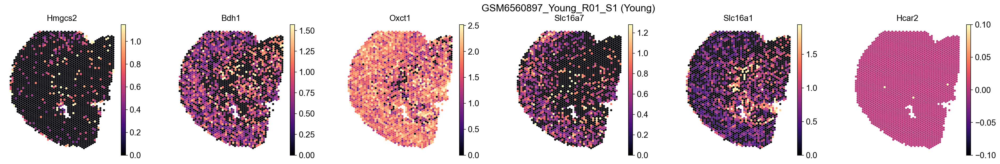

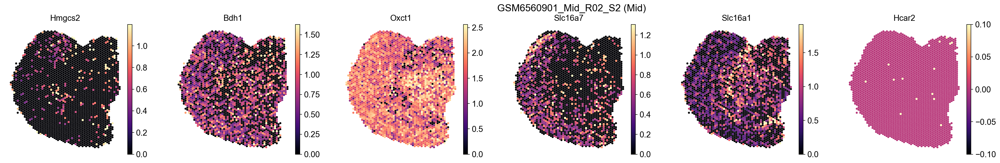

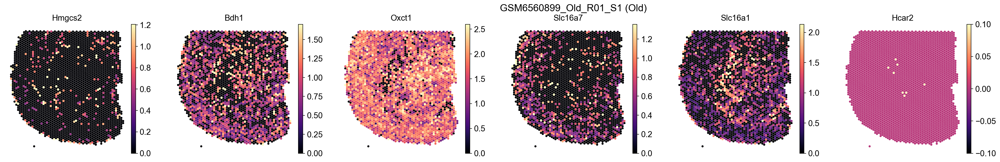

In [4]:
ds = "Visium aging"
ad_vis = None
if PATHS_INHOUSE[ds]:
    ad_vis = sc.read_h5ad(PATHS_INHOUSE[ds]); ad_vis.var_names_make_unique()
    ad_vis.obs["age_group"] = pd.Categorical(ad_vis.obs["age_group"].astype(str), categories=["Young", "Mid", "Old"])
    ad_vis.obs["age_months"] = ad_vis.obs["age_group"].map({"Young": 6, "Mid": 18, "Old": 21}).astype(float)
    wm_genes = om.present(ad_vis, ["Plp1", "Mbp", "Mobp", "Mag", "Cldn11"]); sc.tl.score_genes(ad_vis, wm_genes, score_name="wm_score", use_raw=False)
    ad_vis.obs["wm_rich"] = ad_vis.obs["wm_score"] >= ad_vis.obs["wm_score"].quantile(0.75)
    kg_vis = om.present(ad_vis, KG); print(ad_vis.shape, "| missing:", om.missing(ad_vis, KG))
    results[ds] = {}
    P_vis = om.pathway_scores(ad_vis, KETONE_SCORE_SETS)
    # detection / mean by age group and WM vs non-WM
    ad_vis.obs["compartment_age"] = np.where(ad_vis.obs["wm_rich"], "WM-rich ", "other ") + ad_vis.obs["age_group"].astype(str)
    det = om.detection_table(ad_vis, kg_vis, "compartment_age"); results[ds]["detection_by_compartment_age"] = det
    gene_heat(det, "Visium aging: fraction of spots with ≥1 UMI, by compartment and age", "fraction of spots", row_labels=list(det.index))
    mt = om.mean_table(ad_vis, kg_vis, "compartment_age"); results[ds]["mean_by_compartment_age"] = mt
    gene_heat(mt, "Visium aging: mean log-expression by compartment and age", "mean log-expression", vmin=None, row_labels=list(mt.index))
    # age slopes per section, all spots and WM-rich
    rows = []
    for label, m in [("all spots", np.ones(ad_vis.n_obs, bool)), ("WM-rich", ad_vis.obs["wm_rich"].values)]:
        a_ = ad_vis[m]
        pb = om.pseudobulk(a_, kg_vis, "sample", ["age_group"]); pb["age_months"] = pb["age_group"].map({"Young": 6, "Mid": 18, "Old": 21}).astype(float)
        pbs = om.pseudobulk(a_, [], "sample", ["age_group"], values=P_vis.loc[a_.obs_names]); pbs["age_months"] = pb["age_months"].values
        for g in kg_vis:
            r = stats.linregress(pb["age_months"], pb[g])
            rows.append({"spots": label, "feature": g, "kind": "gene", "pearson_r": r.rvalue, "p": r.pvalue, "mean_Young": pb.loc[pb.age_group == "Young", g].mean(), "mean_Old": pb.loc[pb.age_group == "Old", g].mean(),
                         "log2FC_old_vs_young": om.log2fc(pb.loc[pb.age_group == "Old", g].mean(), pb.loc[pb.age_group == "Young", g].mean())})
        for pw in P_vis.columns:
            r = stats.linregress(pbs["age_months"], pbs[pw])
            rows.append({"spots": label, "feature": pw, "kind": "score", "pearson_r": r.rvalue, "p": r.pvalue, "mean_Young": pbs.loc[pbs.age_group == "Young", pw].mean(), "mean_Old": pbs.loc[pbs.age_group == "Old", pw].mean(), "log2FC_old_vs_young": np.nan})
        del a_
    age = pd.DataFrame(rows); results[ds]["age_trends"] = age
    print("age trends (linear fit over 6 sections):"); display(age.round(4))
    # C4b co-expression within WM-rich spots
    wm = ad_vis[ad_vis.obs["wm_rich"].values].copy()
    co = om.coexpression_with_anchor(wm, "C4b", kg_vis); results[ds]["C4b_coexpr_WM"] = co
    print("ketone genes vs C4b in white-matter-rich spots:"); display(co[["frac_in_C4b-", "frac_in_C4b+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(4))
    del wm
    # maps: one section per age group
    picks = ad_vis.obs.groupby("age_group", observed=True)["sample"].first()
    for age_, s_ in picks.items():
        sub = ad_vis[ad_vis.obs["sample"] == s_].copy()
        hv = om.present(sub, ["Hmgcs2", "Bdh1", "Oxct1", "Slc16a7", "Slc16a1", "Hcar2"])
        sc.pl.spatial(sub, color=[om.resolve(sub, [g])[g] for g in hv], spot_size=90, cmap="magma", vmax="p99", ncols=len(hv), show=False); plt.suptitle(f"{s_} ({age_})", y=1.02); plt.show()
        del sub
    for k, v in results[ds].items():
        v.to_csv(f"../../results/ketone_visium_{k}.csv")
    del ad_vis, P_vis; gc.collect()

---
## 3. Falcão et al. 2018 (sorted single cells): intrinsic ketone handling along the oligodendrocyte lineage

(1765, 18357) | missing: ['Fgf21']


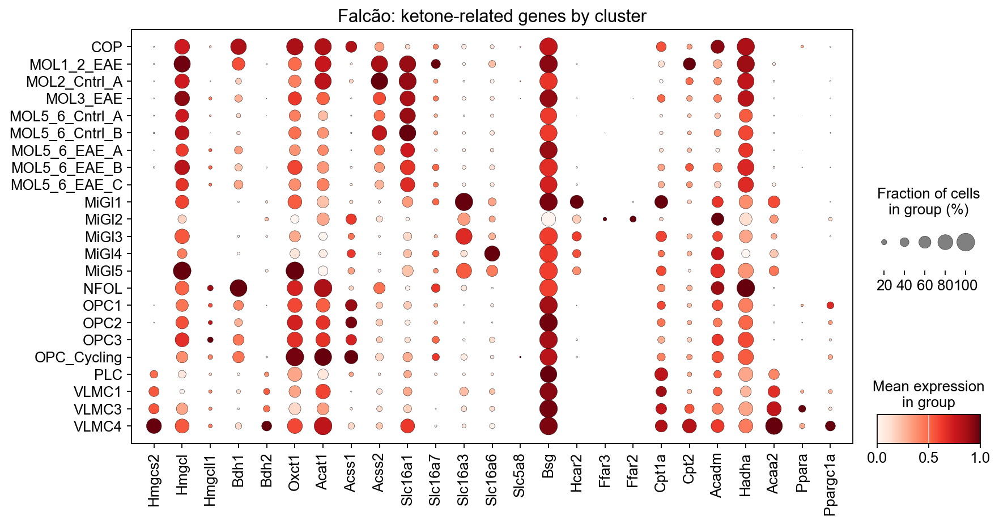

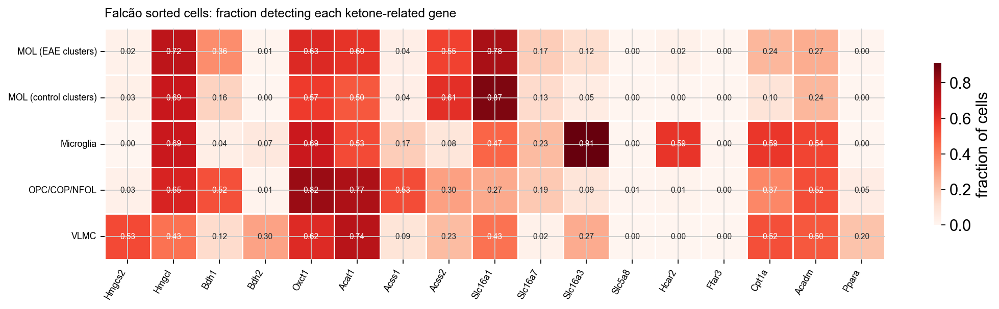

complete ketolytic machinery (Oxct1 and Bdh1 in the same cell):


,n_cells,Oxct1+,Bdh1+,both,both_expected_if_independent
group,,,,,
MOL (EAE clusters),534,0.627,0.356,0.227,0.223
MOL (control clusters),617,0.572,0.156,0.094,0.089
Microglia,213,0.685,0.042,0.028,0.029
OPC/COP/NFOL,313,0.818,0.518,0.454,0.423
VLMC,88,0.625,0.125,0.102,0.078


,n_cells,Oxct1+,Bdh1+,both,both_expected_if_independent
group,,,,,
COP,35,0.914,0.857,0.800,0.784
NFOL,18,0.833,0.944,0.778,0.787
OPC_Cycling,23,1.000,0.565,0.565,0.565
OPC3,41,0.829,0.537,0.463,0.445
MOL1_2_EAE,31,0.677,0.645,0.452,0.437
OPC1,129,0.760,0.465,0.395,0.353
OPC2,55,0.818,0.345,0.291,0.283
MOL5_6_EAE_B,67,0.761,0.313,0.239,0.239
MOL5_6_EAE_C,42,0.595,0.405,0.238,0.241


EAE-MOL vs control-MOL (cells as replicates):


,group,frac_MOL_EAE,frac_MOL_ctrl,mean_MOL_EAE,mean_MOL_ctrl,log2FC,MWU_p_cells
gene,,,,,,,
Hmgcs2,Synthesis (ketogenesis),0.0225,0.0292,0.1161,0.1074,0.1111,0.5559
Hmgcl,Synthesis (ketogenesis),0.7228,0.6937,4.3374,4.2552,0.0276,0.4993
Hmgcll1,Synthesis (ketogenesis),0.0993,0.0421,0.5114,0.2181,1.2254,0.0192
Bdh1,Utilisation (ketolysis),0.3558,0.1556,1.9153,0.8342,1.1981,0.0000
Bdh2,Synthesis (ketogenesis),0.0075,0.0032,0.0229,0.0103,1.0846,0.9783
Oxct1,Utilisation (ketolysis),0.6273,0.5721,4.0940,3.7922,0.1105,0.1414
Acat1,Utilisation (ketolysis),0.5974,0.5008,3.8129,3.0797,0.3080,0.0008
Acss1,Acetate activation,0.0375,0.0389,0.1678,0.1509,0.1519,0.6949
Acss2,Acetate activation,0.5524,0.6062,3.3747,3.9605,-0.2308,0.0068


ketone genes vs C4b in MOL:


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0244,0.0271,1.1129,0.0762,0.8513
Hmgcl,0.6851,0.7214,1.0530,0.0830,0.2074
Hmgcll1,0.0466,0.0829,1.7795,0.1339,0.0171
Bdh1,0.1574,0.3071,1.9510,0.2244,0.0000
Bdh2,0.0000,0.0086,NaN,0.0963,0.0871
Oxct1,0.5676,0.6171,1.0872,0.0815,0.0968
Acat1,0.4767,0.5900,1.2376,0.1714,0.0002
Acss1,0.0443,0.0343,0.7731,0.0665,0.4319
Acss2,0.5743,0.5857,1.0199,0.0076,0.7138


In [5]:
ds = "Falcão EAE sc"
ad_f = None
if PATHS_INHOUSE[ds]:
    ad_f = sc.read_h5ad(PATHS_INHOUSE[ds]); ad_f.var_names_make_unique()
    cl = ad_f.obs["Renamed_clusternames"].astype(str)
    grp = np.select([cl.str.contains("MOL") & cl.str.contains("EAE"), cl.str.contains("MOL"), cl.str.startswith("MiGl"), cl.str.startswith("VLMC"),
                     cl.isin(["OPC1", "OPC2", "OPC3", "OPC_Cycling", "COP", "NFOL", "PLC"])], ["MOL (EAE clusters)", "MOL (control clusters)", "Microglia", "VLMC", "OPC/COP/NFOL"], default="other")
    ad_f.obs["group_coarse"] = pd.Categorical(grp, categories=["OPC/COP/NFOL", "MOL (control clusters)", "MOL (EAE clusters)", "Microglia", "VLMC", "other"])
    kg_f = om.present(ad_f, KG); print(ad_f.shape, "| missing:", om.missing(ad_f, KG))
    results[ds] = {}
    r = om.resolve(ad_f, kg_f)
    sc.pl.dotplot(ad_f, var_names=[r[g] for g in kg_f], groupby="Renamed_clusternames", standard_scale="var", color_map="Reds", figsize=(0.4 * len(kg_f) + 2, 6), show=False, title="Falcão: ketone-related genes by cluster"); plt.show()
    det = om.detection_table(ad_f, kg_f, "group_coarse", min_cells=10); results[ds]["detection_by_group"] = det
    gene_heat(det, "Falcão sorted cells: fraction detecting each ketone-related gene", "fraction of cells", row_labels=list(det.index))
    cd = codetect(ad_f, "group_coarse", min_cells=10); results[ds]["codetect_Oxct1_Bdh1"] = cd
    print("complete ketolytic machinery (Oxct1 and Bdh1 in the same cell):"); display(cd.round(3))
    cd_cl = codetect(ad_f, "Renamed_clusternames", min_cells=8); results[ds]["codetect_by_cluster"] = cd_cl; display(cd_cl.round(3).sort_values("both", ascending=False))
    # EAE-MOL vs control-MOL, gene-wise
    m_eae = (ad_f.obs["group_coarse"] == "MOL (EAE clusters)").values; m_ctl = (ad_f.obs["group_coarse"] == "MOL (control clusters)").values
    df = om.expr_df(ad_f, kg_f); rows = []
    for g in df.columns:
        x = df[g].values
        rows.append({"gene": g, "group": GROUP_OF.get(g), "frac_MOL_EAE": (x[m_eae] > 0).mean(), "frac_MOL_ctrl": (x[m_ctl] > 0).mean(), "mean_MOL_EAE": x[m_eae].mean(), "mean_MOL_ctrl": x[m_ctl].mean(),
                     "log2FC": om.log2fc(x[m_eae].mean(), x[m_ctl].mean()), "MWU_p_cells": stats.mannwhitneyu(x[m_eae], x[m_ctl]).pvalue if x.std() > 0 else np.nan})
    t = pd.DataFrame(rows).set_index("gene"); results[ds]["MOL_EAE_vs_ctrl"] = t
    print("EAE-MOL vs control-MOL (cells as replicates):"); display(t.round(4))
    # C4b co-expression in MOL
    mol = ad_f[ad_f.obs["group_coarse"].isin(["MOL (control clusters)", "MOL (EAE clusters)"])].copy()
    co = om.coexpression_with_anchor(mol, "C4b", kg_f); results[ds]["C4b_coexpr_MOL"] = co
    print("ketone genes vs C4b in MOL:"); display(co[["frac_in_C4b-", "frac_in_C4b+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(4))
    del mol
    for k, v in results[ds].items():
        v.to_csv(f"../../results/ketone_falcao_{k}.csv")
    del ad_f; gc.collect()

---
## 4. Public datasets: per-dataset pass

For each dataset: detection and mean expression of every ketone gene by coarse cell type; *Oxct1* + *Bdh1* co-detection; ketogenesis / ketolysis /
fatty-acid-supply scores by cell type; pseudobulk contrasts for every cell type, gene-wise and score-wise; *Hmgcs2* coupling inside astrocytes; *C4b*
co-expression inside oligodendrocytes (mouse); by-condition tables (human). Cross-dataset summaries follow in section 5.


Absinta2021_MS_human_snRNA: 66432 cells | human snRNA | missing ketone genes: ['Fgf21']


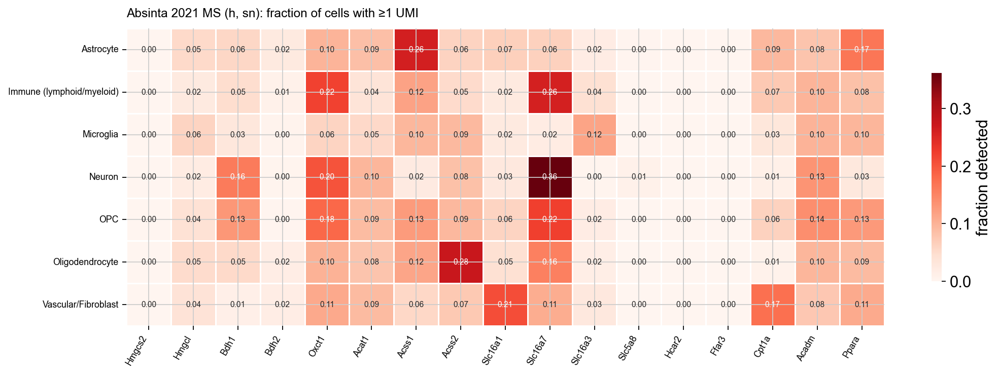


Aging_snRNA_HIP_CP_mouse: 109822 cells | mouse snRNA | missing ketone genes: []


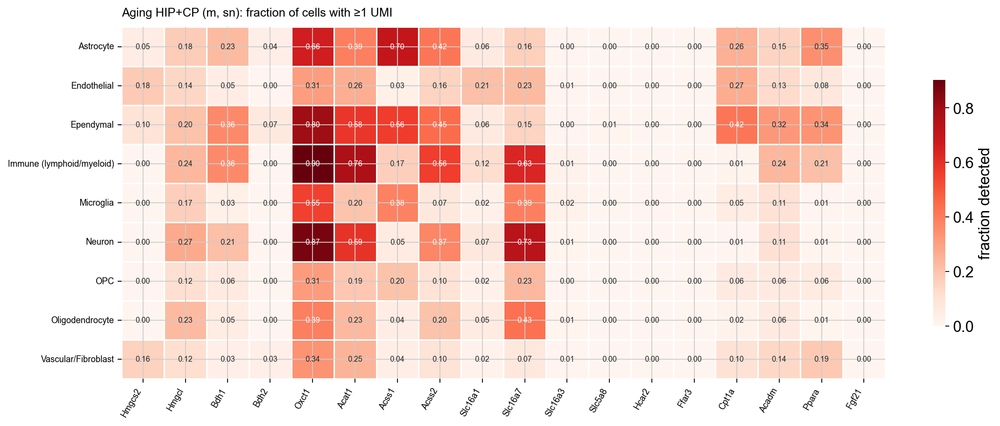

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.2555,0.2943,1.1520,0.0125,0.0334
Acadm,0.1478,0.2000,1.3529,0.0277,0.0006
Hadha,0.3101,0.3626,1.1694,0.0180,0.0074
Ppara,0.3432,0.4195,1.2224,0.0298,0.0001
Bdh1,0.2272,0.2358,1.0379,0.0016,0.6221
Hmgcl,0.1745,0.1984,1.1369,0.0124,0.1285
Slc16a3,0.0047,0.0016,0.3445,-0.0101,0.5302
Gfap,0.2716,0.2699,0.9940,-0.0042,0.9629


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0008,0.0012,1.5472,0.0052,0.4532
Hmgcl,0.2302,0.2202,0.9566,-0.0132,0.2766
Hmgcll1,0.1396,0.1577,1.1297,0.0098,0.0161
Bdh1,0.0501,0.0558,1.1135,0.0036,0.2265
Bdh2,0.0009,0.0008,0.8381,-0.0017,1.0000
Oxct1,0.3935,0.3936,1.0004,-0.0085,1.0000
Acat1,0.2276,0.2407,1.0575,0.0038,0.1426
Acss1,0.0432,0.0378,0.8745,-0.0113,0.2252
Acss2,0.2023,0.2072,1.0242,0.0003,0.5611



Chen2020_ST_AppNLGF_mouse: 19021 cells | mouse spatial | missing ketone genes: []


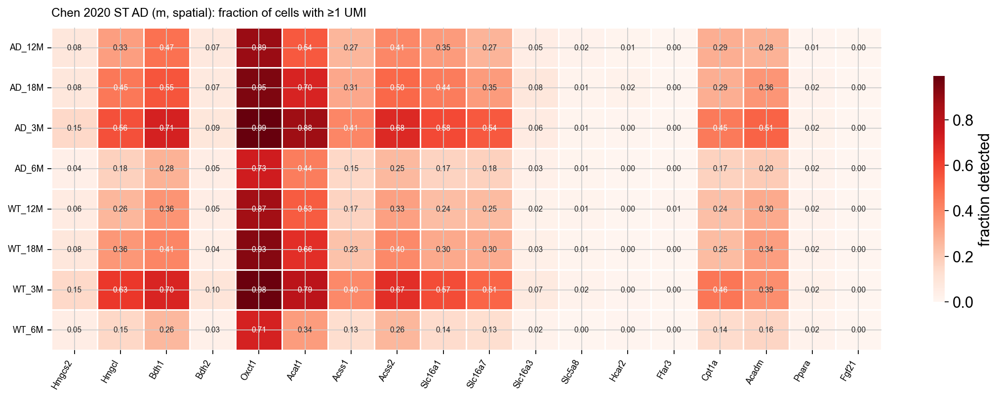

mean log-expression by group_age:


,Hmgcs2,Hmgcl,Bdh1,Bdh2,Oxct1,Acat1,Acss1,Acss2,Slc16a1,Slc16a7,Slc16a3,Slc5a8,Hcar2,Ffar3,Cpt1a,Acadm,Ppara,Fgf21
WT_3M,0.048,0.332,0.316,0.028,1.134,0.425,0.141,0.284,0.224,0.190,0.021,0.004,0.002,0.001,0.163,0.131,0.006,0.000
AD_3M,0.042,0.193,0.282,0.022,1.137,0.483,0.123,0.269,0.202,0.182,0.017,0.002,0.001,0.000,0.138,0.167,0.006,0.000
WT_18M,0.042,0.184,0.212,0.019,1.005,0.437,0.107,0.206,0.145,0.144,0.017,0.003,0.001,0.000,0.121,0.165,0.007,0.000
AD_18M,0.033,0.204,0.260,0.025,1.007,0.416,0.125,0.230,0.186,0.141,0.033,0.004,0.008,0.000,0.119,0.151,0.006,0.000
WT_6M,0.036,0.116,0.201,0.021,0.829,0.283,0.087,0.195,0.102,0.095,0.014,0.002,0.002,0.000,0.106,0.114,0.011,0.001
AD_6M,0.022,0.115,0.167,0.026,0.755,0.313,0.091,0.152,0.098,0.104,0.018,0.004,0.001,0.000,0.102,0.119,0.007,0.001
WT_12M,0.041,0.159,0.235,0.024,0.991,0.383,0.095,0.212,0.146,0.148,0.010,0.006,0.002,0.004,0.147,0.186,0.008,0.000
AD_12M,0.042,0.189,0.290,0.036,0.994,0.374,0.135,0.230,0.182,0.148,0.028,0.008,0.005,0.001,0.161,0.158,0.002,0.000



Jakel2019_MS_human_snRNA: 17790 cells | human snRNA | missing ketone genes: ['Hmgcs2', 'Hcar2', 'Ffar3', 'Ffar2', 'Fgf21']


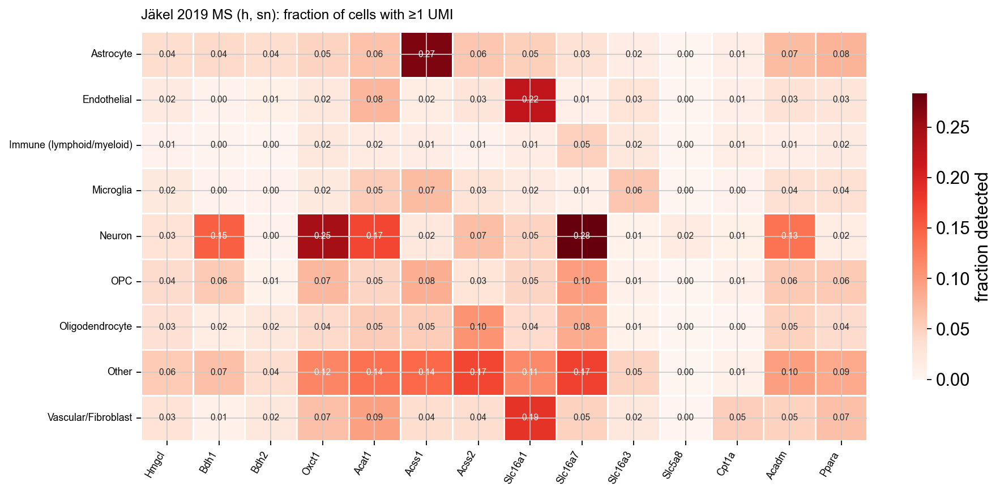


Kaya2022_aged_WM_vs_GM_scRNA: 29623 cells | mouse scRNA | missing ketone genes: ['Slc5a8', 'Ffar3', 'Fgf21']


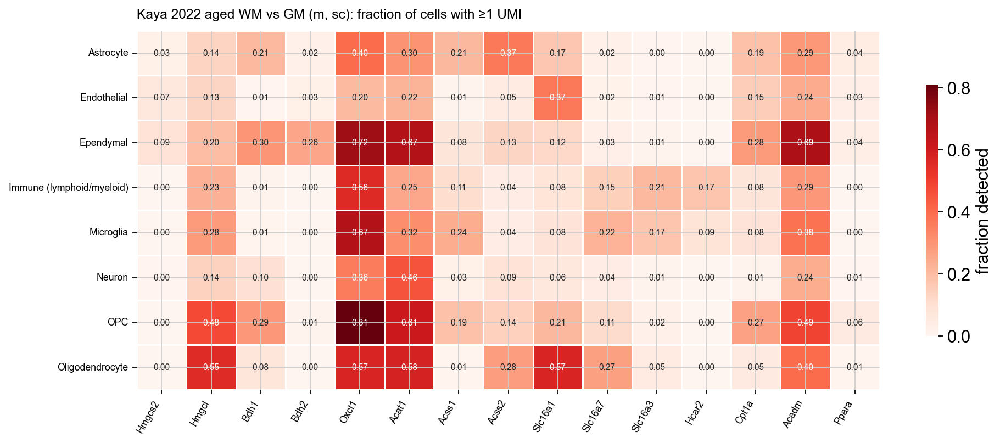

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.1836,0.3519,1.9163,0.0651,0.0040
Acadm,0.2885,0.4444,1.5408,0.0436,0.0217
Hadha,0.3896,0.4444,1.1409,0.0163,0.4797
Ppara,0.0452,0.0185,0.4094,-0.0222,0.5137
Bdh1,0.2028,0.3519,1.7352,0.0535,0.0156
Hmgcl,0.1346,0.2593,1.9255,0.0577,0.0149
Slc16a3,0.0037,0.0000,0.0000,-0.0102,1.0000
Gfap,0.1958,0.2037,1.0401,-0.0001,0.8625


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0003,0.0012,4.2366,0.0146,0.2170
Hmgcl,0.5345,0.5597,1.0472,-0.0100,0.0075
Hmgcll1,0.0044,0.0243,5.5606,0.0958,0.0000
Bdh1,0.0859,0.0729,0.8483,-0.0392,0.0104
Bdh2,0.0005,0.0008,1.5131,0.0106,0.7445
Oxct1,0.5632,0.5736,1.0185,-0.0168,0.2693
Acat1,0.5402,0.5924,1.0966,0.0200,0.0000
Acss1,0.0123,0.0083,0.6725,-0.0224,0.0295
Acss2,0.2704,0.2779,1.0279,-0.0270,0.3760



LPC_Cuprizone_CC_snRNA_mouse: 30338 cells | mouse snRNA | missing ketone genes: ['Ffar2', 'Fgf21']


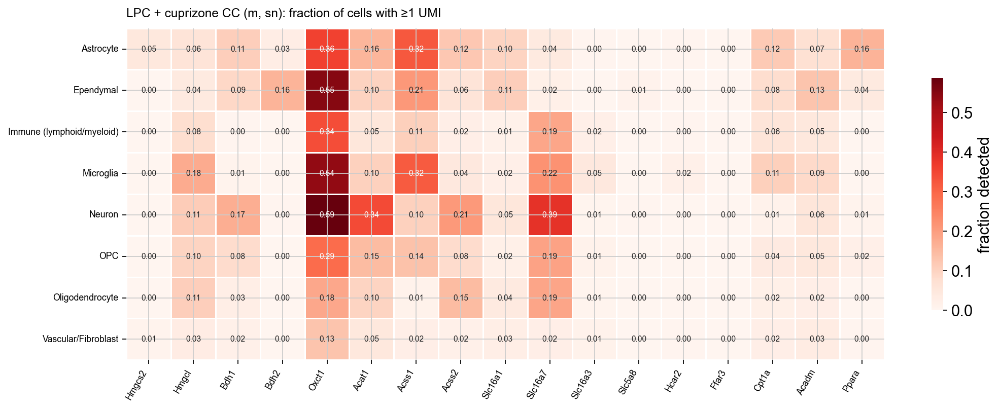

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.1119,0.225,2.0098,0.0697,0.0414
Acadm,0.0654,0.225,3.4399,0.1189,0.0015
Hadha,0.1572,0.275,1.7490,0.0562,0.0749
Ppara,0.1572,0.250,1.5900,0.0461,0.1249
Bdh1,0.1031,0.225,2.1814,0.0702,0.0315
Hmgcl,0.0528,0.200,3.7857,0.1253,0.0016
Slc16a3,0.0038,0.000,0.0000,-0.0135,1.0000
Gfap,0.5572,0.775,1.3908,0.0862,0.0081


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0011,0.0024,2.2798,0.0124,0.1375
Hmgcl,0.1005,0.1649,1.6417,0.0578,0.0000
Hmgcll1,0.0435,0.0834,1.9161,0.0570,0.0000
Bdh1,0.0243,0.0383,1.5783,0.0249,0.0016
Bdh2,0.0004,0.0012,3.4197,0.0131,0.1721
Oxct1,0.1750,0.2325,1.3282,0.0333,0.0000
Acat1,0.0909,0.1351,1.4871,0.0399,0.0000
Acss1,0.0122,0.0183,1.4977,0.0154,0.0470
Acss2,0.1386,0.1984,1.4311,0.0414,0.0000



Leng2021_AD_human_snRNA: 92199 cells | human snRNA | missing ketone genes: ['Fgf21']


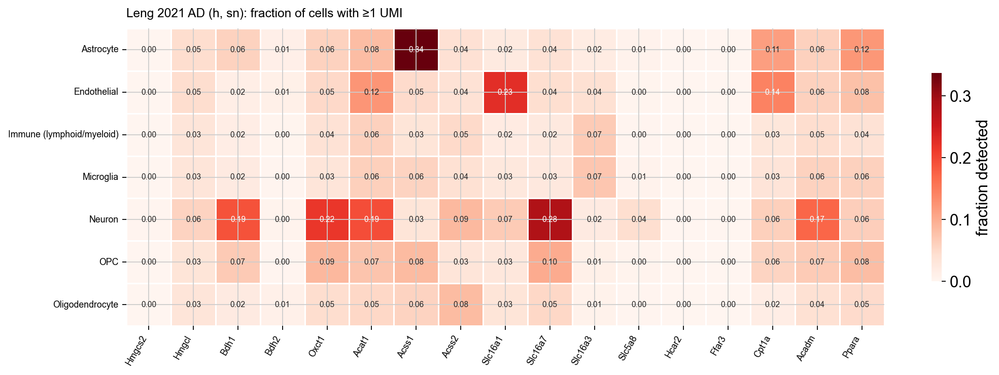


LermaMartin2024_MS_human_Visium: 70238 cells | human spatial | missing ketone genes: ['Hmgcs2', 'Fgf21']


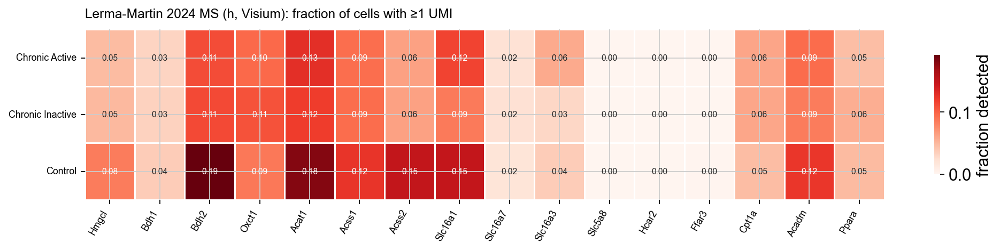

mean log-expression by condition_original:


,Hmgcl,Bdh1,Bdh2,Oxct1,Acat1,Acss1,Acss2,Slc16a1,Slc16a7,Slc16a3,Slc5a8,Hcar2,Ffar3,Cpt1a,Acadm,Ppara
Chronic Active,0.059,0.035,0.151,0.121,0.173,0.122,0.080,0.174,0.025,0.086,0.0,0.001,0.001,0.085,0.125,0.065
Control,0.112,0.047,0.273,0.113,0.249,0.166,0.205,0.209,0.025,0.051,0.0,0.000,0.001,0.061,0.169,0.062
Chronic Inactive,0.080,0.038,0.178,0.160,0.183,0.146,0.102,0.137,0.033,0.056,0.0,0.000,0.000,0.099,0.127,0.089



LermaMartin2024_MS_human_snRNA: 102672 cells | human snRNA | missing ketone genes: ['Hcar2', 'Ffar2', 'Fgf21']


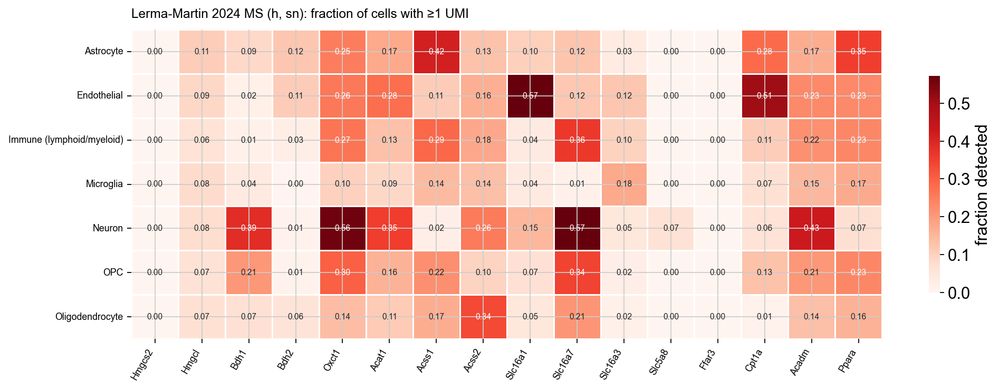


Park2023_AD_hippocampus_scRNA: 47660 cells | mouse scRNA | missing ketone genes: ['Fgf21']


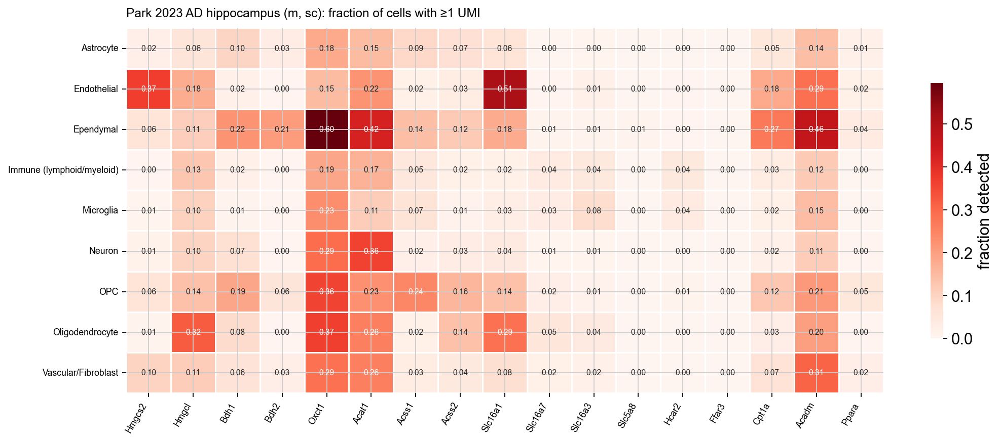

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.0503,0.1258,2.4990,0.0486,0.0002
Acadm,0.1424,0.2327,1.6343,0.0330,0.0028
Hadha,0.0811,0.1195,1.4733,0.0186,0.1052
Ppara,0.0144,0.0314,2.1896,0.0200,0.0850
Bdh1,0.0970,0.0881,0.9079,-0.0067,0.7875
Hmgcl,0.0561,0.0566,1.0093,-0.0002,0.8628
Slc16a3,0.0048,0.0126,2.6275,0.0159,0.1857
Gfap,0.1691,0.2956,1.7485,0.0439,0.0001


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0081,0.0093,1.1383,0.0022,0.6543
Hmgcl,0.3163,0.3858,1.2197,0.0185,0.0003
Hmgcll1,0.0040,0.0123,3.1153,0.0287,0.0076
Bdh1,0.0799,0.1188,1.4875,0.0299,0.0009
Bdh2,0.0029,0.0077,2.6425,0.0194,0.0546
Oxct1,0.3609,0.4676,1.2955,0.0351,0.0000
Acat1,0.2539,0.3611,1.4221,0.0451,0.0000
Acss1,0.0206,0.0247,1.1958,0.0063,0.4767
Acss2,0.1373,0.1651,1.2023,0.0144,0.0528



Sadick2022_AD_human_astro_oligo_snRNA: 107392 cells | human snRNA | missing ketone genes: []


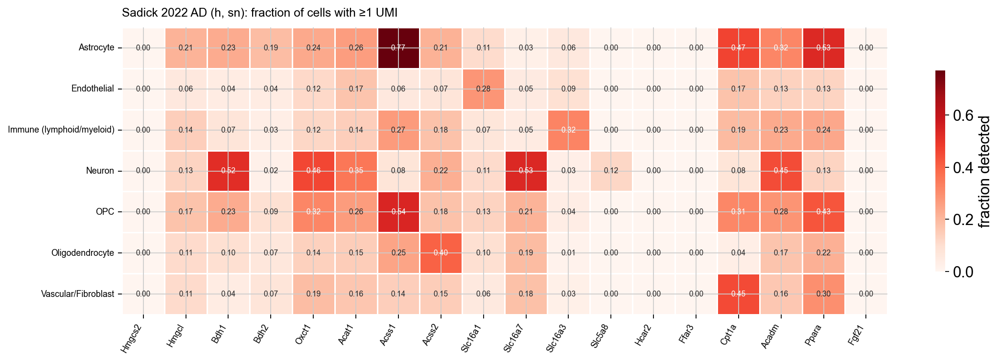

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.4657,0.6250,1.3420,0.0065,0.0219
Acadm,0.3161,0.3750,1.1863,0.0035,0.3881
Hadha,0.4755,0.4464,0.9389,-0.0057,0.6900
Ppara,0.5325,0.6250,1.1737,0.0060,0.1816
Bdh1,0.2293,0.3214,1.4016,0.0061,0.1114
Hmgcl,0.2124,0.3393,1.5972,0.0082,0.0318
Slc16a3,0.0583,0.0357,0.6123,-0.0032,0.7723
Gfap,0.9427,0.9464,1.0039,-0.0063,1.0000



Schirmer2019_MS_human_snRNA: 48919 cells | human snRNA | missing ketone genes: ['Hcar2', 'Fgf21']


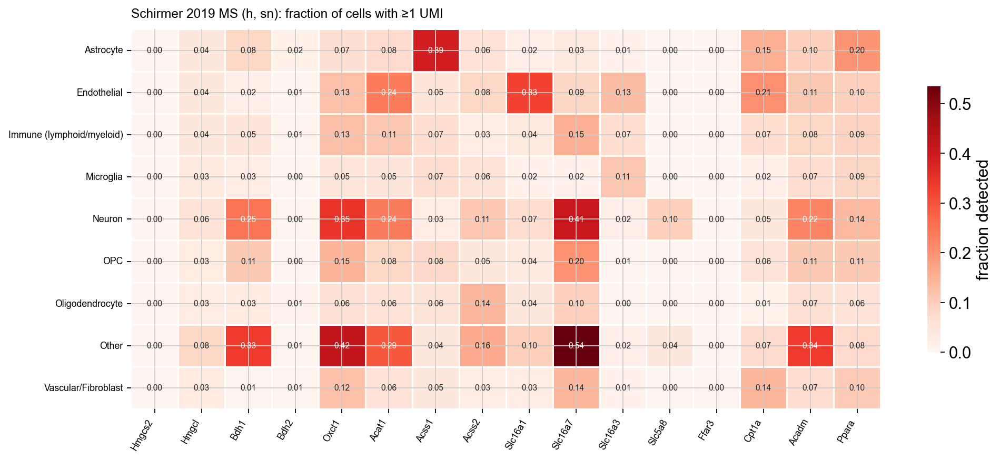


SenescentGlia2025_MS_human_Visium: 27619 cells | human spatial | missing ketone genes: ['Hmgcs2', 'Hcar2', 'Ffar3', 'Fgf21']


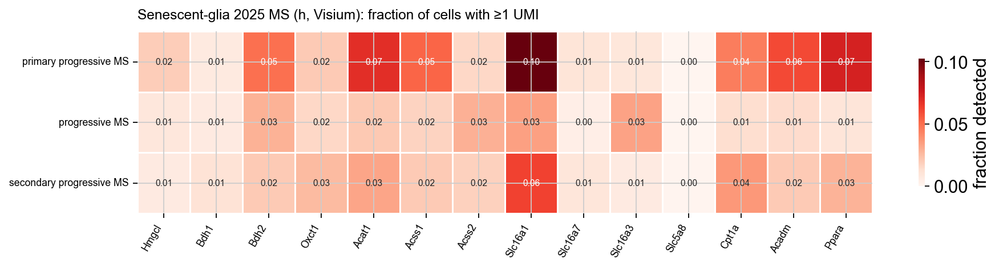

mean log-expression by condition_original:


,Hmgcl,Bdh1,Bdh2,Oxct1,Acat1,Acss1,Acss2,Slc16a1,Slc16a7,Slc16a3,Slc5a8,Cpt1a,Acadm,Ppara
secondary progressive MS,0.014,0.021,0.044,0.049,0.066,0.043,0.042,0.142,0.018,0.015,0.001,0.080,0.044,0.062
progressive MS,0.026,0.020,0.087,0.049,0.064,0.055,0.088,0.100,0.011,0.107,0.000,0.038,0.045,0.030
primary progressive MS,0.036,0.015,0.093,0.037,0.143,0.098,0.042,0.209,0.021,0.021,0.000,0.084,0.115,0.146



Serpina3n_Cuprizone_snRNA_mouse: 52437 cells | mouse snRNA | missing ketone genes: ['Ffar3']


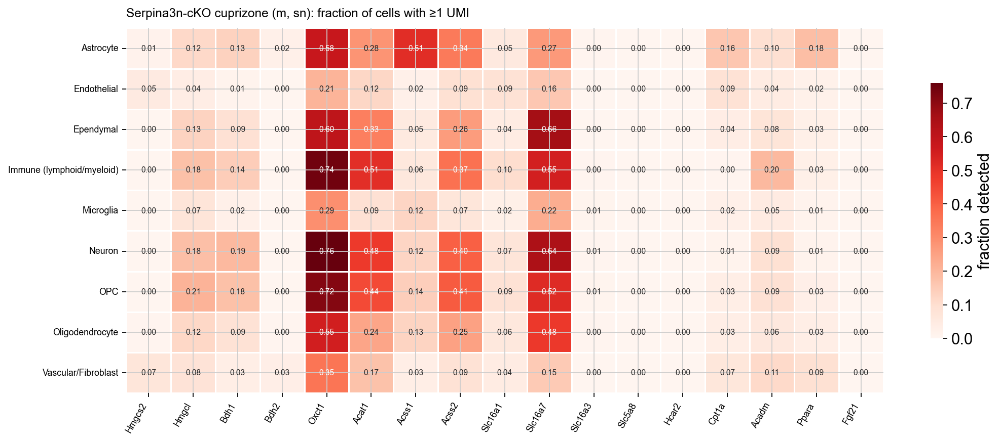

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.1626,0.175,1.0765,0.0039,0.8290
Acadm,0.0967,0.100,1.0346,-0.0000,0.7918
Hadha,0.2227,0.300,1.3472,0.0197,0.2524
Ppara,0.1820,0.175,0.9614,-0.0040,1.0000
Bdh1,0.1311,0.175,1.3344,0.0138,0.4762
Hmgcl,0.1137,0.225,1.9784,0.0399,0.0416
Slc16a3,0.0044,0.000,0.0000,-0.0078,1.0000
Gfap,0.1086,0.150,1.3811,0.0130,0.4381


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0036,0.0266,7.3542,0.0525,0.0010
Hmgcl,0.1112,0.3564,3.2039,0.1053,0.0000
Hmgcll1,0.4516,0.4521,1.0013,-0.0223,1.0000
Bdh1,0.0855,0.2074,2.4250,0.0565,0.0000
Bdh2,0.0027,0.0213,7.7553,0.0487,0.0027
Oxct1,0.5511,0.6649,1.2066,0.0188,0.0018
Acat1,0.2399,0.3564,1.4854,0.0233,0.0004
Acss1,0.1216,0.3564,2.9311,0.0994,0.0000
Acss2,0.2503,0.3457,1.3814,0.0157,0.0038



Ximerakis2019_aging_brain_scRNA: 37069 cells | mouse scRNA | missing ketone genes: ['Ffar3', 'Ffar2', 'Fgf21']


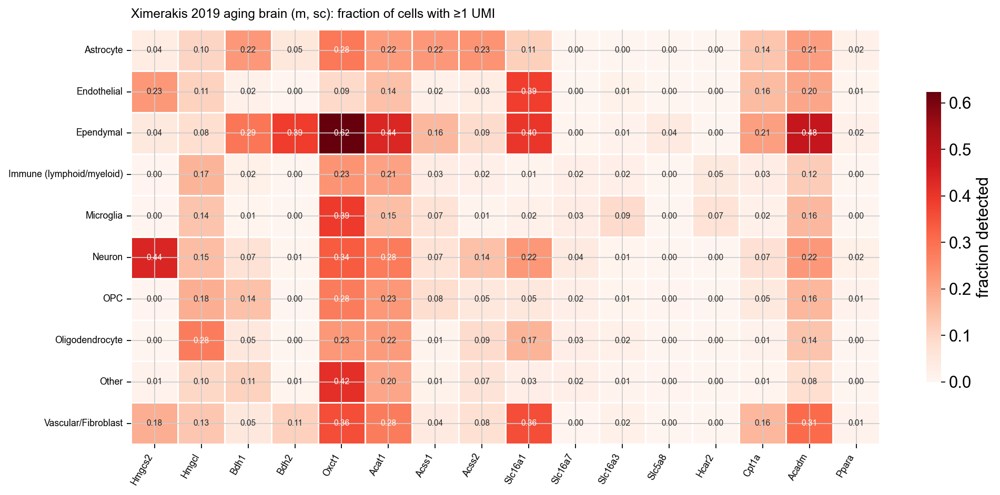

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.1329,0.1959,1.4744,0.0336,0.0074
Acadm,0.2082,0.3224,1.5484,0.0460,0.0000
Hadha,0.2165,0.3020,1.3948,0.0304,0.0021
Ppara,0.0166,0.0163,0.9829,-0.0004,1.0000
Bdh1,0.2213,0.2327,1.0512,0.0019,0.6953
Hmgcl,0.1020,0.1102,1.0808,0.0040,0.6672
Slc16a3,0.0009,0.0000,0.0000,-0.0058,1.0000
Gfap,0.2364,0.3878,1.6403,0.0637,0.0000


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0022,0.0010,0.4742,-0.0092,0.4126
Hmgcl,0.2689,0.3163,1.1763,0.0201,0.0000
Hmgcll1,0.0031,0.0026,0.8521,-0.0031,1.0000
Bdh1,0.0488,0.0375,0.7684,-0.0230,0.0301
Bdh2,0.0011,0.0021,1.8178,0.0103,0.2951
Oxct1,0.2184,0.2637,1.2071,0.0246,0.0000
Acat1,0.2087,0.2642,1.2660,0.0306,0.0000
Acss1,0.0077,0.0068,0.8752,-0.0063,0.7749
Acss2,0.0852,0.0990,1.1616,0.0098,0.0529



Zhou2020_5XFAD_snRNA: 125858 cells | mouse snRNA | missing ketone genes: []


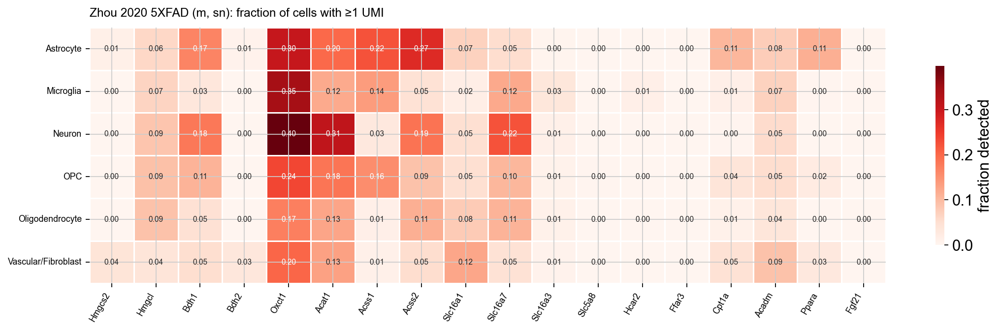

astrocytes: genes vs Hmgcs2


,frac_in_Hmgcs2-,frac_in_Hmgcs2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Cpt1a,0.1037,0.21,2.0252,0.0375,0.0016
Acadm,0.0750,0.13,1.7326,0.0223,0.0536
Hadha,0.1772,0.31,1.7496,0.0338,0.0014
Ppara,0.1137,0.14,1.2316,0.0068,0.4263
Bdh1,0.1661,0.19,1.1440,0.0054,0.5002
Hmgcl,0.0610,0.06,0.9839,-0.0009,1.0000
Slc16a3,0.0041,0.00,0.0000,-0.0075,1.0000
Gfap,0.1429,0.28,1.9594,0.0470,0.0005


oligodendrocytes: ketone genes vs C4b


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Hmgcs2,0.0005,0.0000,0.0000,-0.0075,1.0000
Hmgcl,0.0916,0.0886,0.9679,-0.0071,0.6894
Hmgcll1,0.0395,0.0371,0.9389,-0.0094,0.6354
Bdh1,0.0476,0.0408,0.8574,-0.0157,0.1730
Bdh2,0.0004,0.0000,0.0000,-0.0070,1.0000
Oxct1,0.1748,0.1559,0.8920,-0.0246,0.0305
Acat1,0.1276,0.1132,0.8876,-0.0195,0.0609
Acss1,0.0141,0.0167,1.1811,0.0039,0.3357
Acss2,0.1135,0.1216,1.0714,0.0017,0.2781



done: 16 datasets; 0 failed []


In [6]:
DET, MEAN, CODET, SCORE_CT, DE, DE_S, ASTRO, CO, COND, INFO, ERR = [], [], [], [], [], [], {}, {}, {}, {}, {}
for name, path in PATHS_PUBLIC.items():
    try:
        a = sc.read_h5ad(path); a.obs["cell_type_coarse"] = a.obs["cell_type_coarse"].astype(str)
        species, modality = str(a.obs["species"].iloc[0]), str(a.obs["modality"].iloc[0]); ref, alts = om.alt_groups(a)
        INFO[name] = {"species": species, "modality": modality, "n_cells": a.n_obs, "n_samples": a.obs["sample"].nunique()}
        kg = om.present(a, KG)
        print(f"\n{'=' * 110}\n{name}: {a.n_obs} cells | {species} {modality} | missing ketone genes: {om.missing(a, KG)}")
        P = om.pathway_scores(a, KETONE_SCORE_SETS)
        key_ct = "cell_type_coarse"
        if modality == "spatial":
            key_ct = "group_age" if "age" in a.obs else ("condition_original" if "condition_original" in a.obs else "group")
            if key_ct == "group_age":
                a.obs["group_age"] = a.obs["group"].astype(str) + "_" + a.obs["age"].astype(str)
        det = om.detection_table(a, kg, key_ct, min_cells=30); det.insert(0, "dataset", name); DET.append(det.reset_index().rename(columns={"group": "cell_type"}))
        mt = om.mean_table(a, kg, key_ct, min_cells=30); mt.insert(0, "dataset", name); MEAN.append(mt.reset_index().rename(columns={"index": "cell_type"}))
        cd = codetect(a, key_ct)
        if len(cd):
            cd.insert(0, "dataset", name); CODET.append(cd.reset_index().rename(columns={"group": "cell_type"}))
        s_ct = P.groupby(a.obs[key_ct].astype(str).values).mean(); n_ct = a.obs[key_ct].astype(str).value_counts(); s_ct = s_ct.loc[n_ct[n_ct >= 30].index.intersection(s_ct.index)]
        s_ct.insert(0, "dataset", name); SCORE_CT.append(s_ct.reset_index().rename(columns={"index": "cell_type"}))
        gene_heat(det.drop(columns="dataset"), f"{short(name)}: fraction of cells with ≥1 UMI", "fraction detected", row_labels=list(det.index))
        # contrasts per cell type (or per spot)
        groups_ct = [c for c in CTS_TEST if c in a.obs[key_ct].unique()] if modality != "spatial" else ["spot"]
        for ct in groups_ct:
            m_ct = (a.obs[key_ct] == ct).values if modality != "spatial" else np.ones(a.n_obs, bool)
            if m_ct.sum() < 50 or not alts:
                continue
            sub = a[m_ct]; n = sub.obs.groupby("sample", observed=True).size(); ok = n[n >= 20].index
            pb = om.pseudobulk(sub, kg); pb = pb[pb["sample"].isin(ok)]
            pbs = om.pseudobulk(sub, [], values=P.loc[sub.obs_names]); pbs = pbs[pbs["sample"].isin(ok)]
            for alt in alts:
                for g in [c for c in pb.columns if c in kg]:
                    ma, mr, p, na, nr = om.group_test(pb, g, "group", alt, ref)
                    DE.append({"dataset": name, "cell_type": ct, "gene": g, "group_of": GROUP_OF.get(g), "alt": alt, "ref": ref, "mean_alt": ma, "mean_ref": mr, "log2FC": om.log2fc(ma, mr), "MWU_p": p, "n_alt": na, "n_ref": nr})
                for pw in P.columns:
                    ma, mr, p, na, nr = om.group_test(pbs, pw, "group", alt, ref)
                    DE_S.append({"dataset": name, "cell_type": ct, "score": pw, "alt": alt, "ref": ref, "mean_alt": ma, "mean_ref": mr, "diff": ma - mr, "MWU_p": p, "n_alt": na, "n_ref": nr})
            del sub
        if modality != "spatial":
            ac = astro_coupling(a, (a.obs["cell_type_coarse"] == "Astrocyte").values)
            if len(ac):
                ASTRO[name] = ac; print("astrocytes: genes vs Hmgcs2"); display(ac[["frac_in_Hmgcs2-", "frac_in_Hmgcs2+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(4))
            ol = a[(a.obs["cell_type_coarse"] == "Oligodendrocyte").values].copy()
            if species == "mouse" and ol.n_obs >= 100 and om.resolve(ol, ["C4b"])["C4b"] is not None and (om.expr(ol, "C4b") > 0).sum() >= 50:
                CO[name] = om.coexpression_with_anchor(ol, "C4b", kg); print("oligodendrocytes: ketone genes vs C4b"); display(CO[name][["frac_in_C4b-", "frac_in_C4b+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(4))
            del ol
            key = "condition_original" if ("condition_original" in a.obs and a.obs["condition_original"].nunique() > 1) else ("braak" if "braak" in a.obs else None)
            if key:
                for ct in ["Oligodendrocyte", "Astrocyte", "Microglia", "OPC", "Neuron"]:
                    m_ct = (a.obs["cell_type_coarse"] == ct).values
                    if m_ct.sum() >= 50:
                        sub = a[m_ct]; t = om.detection_table(sub, kg, key, min_cells=30); t2 = om.mean_table(sub, kg, key, min_cells=30)
                        COND[(name, ct, "detection")] = t; COND[(name, ct, "mean")] = t2; del sub
        else:
            print(f"mean log-expression by {key_ct}:"); display(mt.drop(columns="dataset")[[g for g in CORE if g in mt.columns]].round(3))
    except Exception as exc:
        ERR[name] = traceback.format_exc(); print(f"!! {name} failed: {type(exc).__name__}: {exc}")
    finally:
        for v in ["a", "P", "sub", "ol"]:
            if v in globals():
                del globals()[v]
        gc.collect()
DET, MEAN, SCORE_CT, DE, DE_S = pd.concat(DET, ignore_index=True), pd.concat(MEAN, ignore_index=True), pd.concat(SCORE_CT, ignore_index=True), pd.DataFrame(DE), pd.DataFrame(DE_S)
CODET = pd.concat(CODET, ignore_index=True) if CODET else pd.DataFrame()
print("\ndone:", len(INFO), "datasets;", len(ERR), "failed", list(ERR))
for k, v in ERR.items():
    print(k, v)

## 5. Who makes, who uses, who transports and who senses ketone bodies?

Detection of each ketone gene by coarse cell type, averaged over the mouse whole-cell datasets and over the mouse nucleus datasets separately (nuclei detect
cytoplasmic / mitochondrial transcripts less), and over the human nucleus datasets.

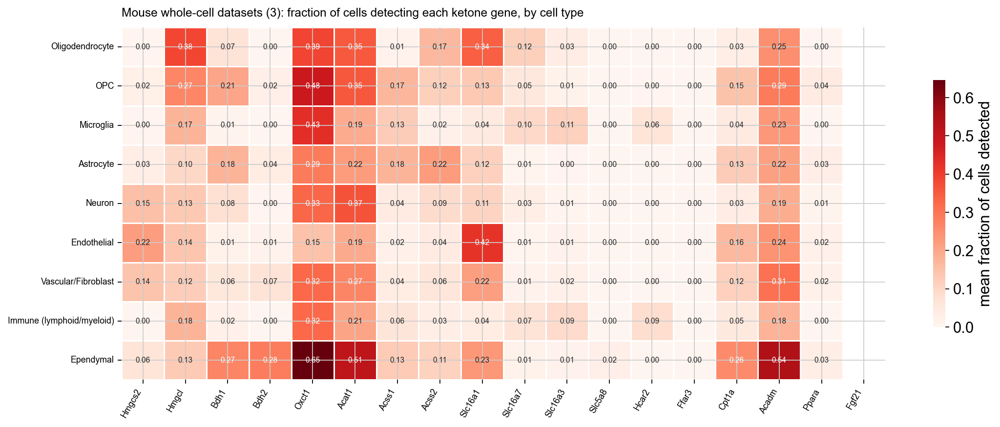

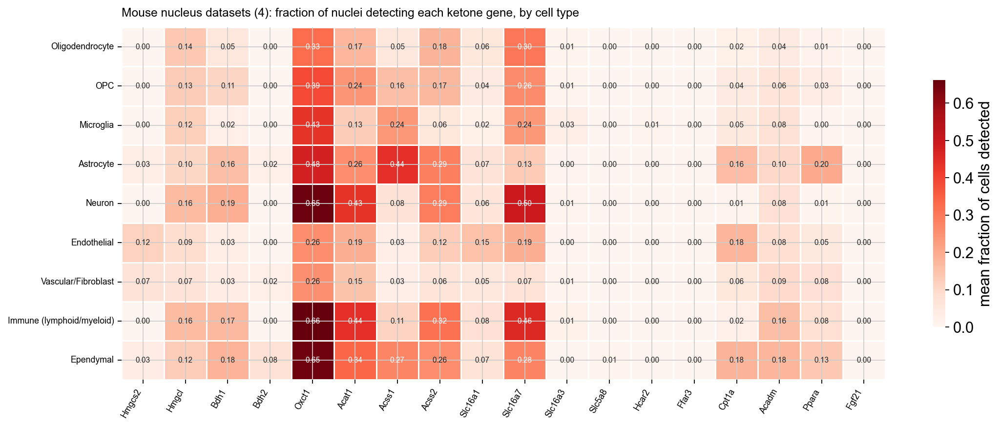

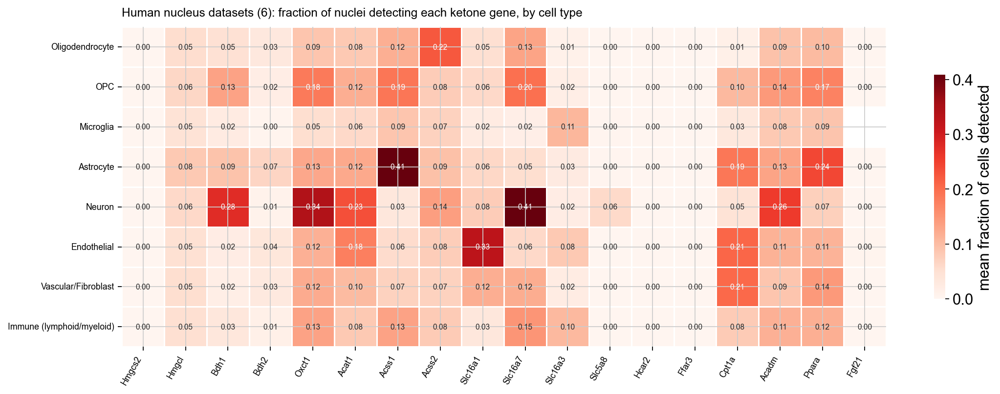

complete ketolytic machinery (Oxct1 and Bdh1 in the same cell), mean over datasets:


,Oxct1+,Bdh1+,both,both_expected_if_independent
cell_type,,,,
Oligodendrocyte,0.230,0.054,0.022,0.015
OPC,0.316,0.142,0.070,0.056
Microglia,0.274,0.020,0.008,0.005
Astrocyte,0.272,0.132,0.056,0.044
Neuron,0.434,0.205,0.129,0.096
Endothelial,0.153,0.020,0.008,0.004
Vascular/Fibroblast,0.216,0.032,0.014,0.008
Immune (lymphoid/myeloid),0.313,0.064,0.042,0.040
Ependymal,0.648,0.225,0.179,0.153


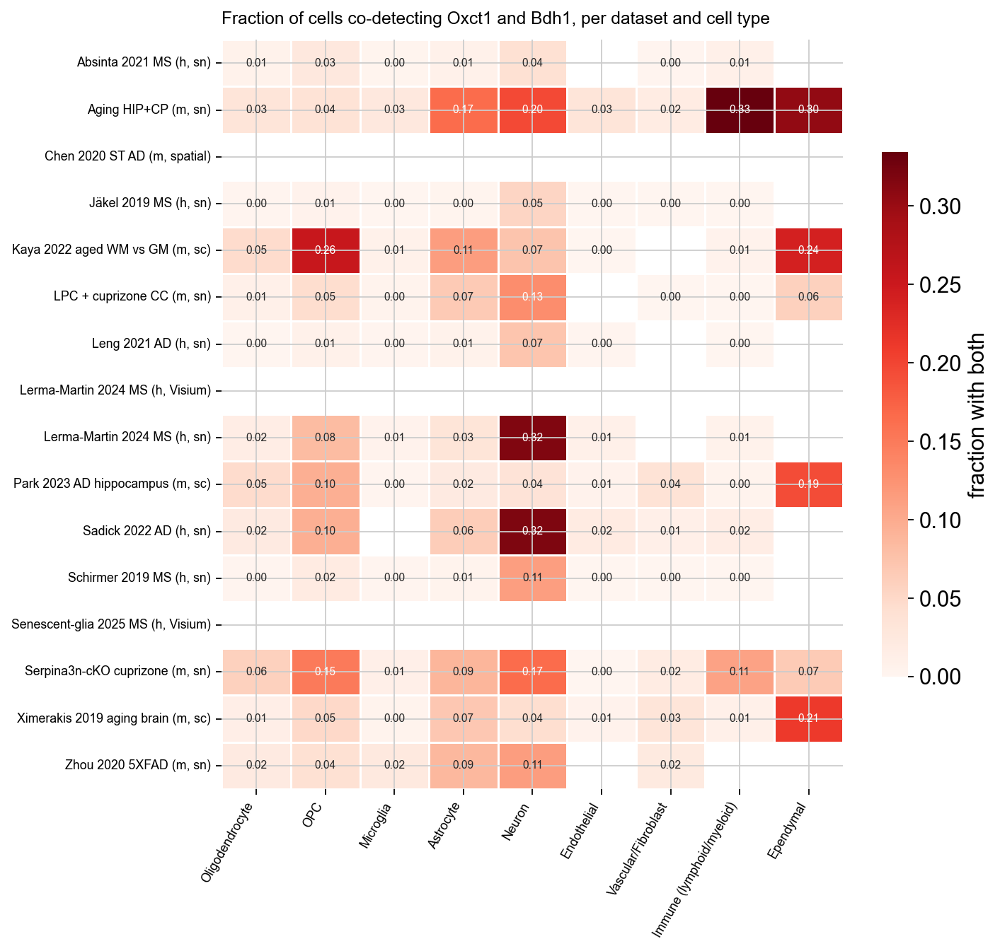

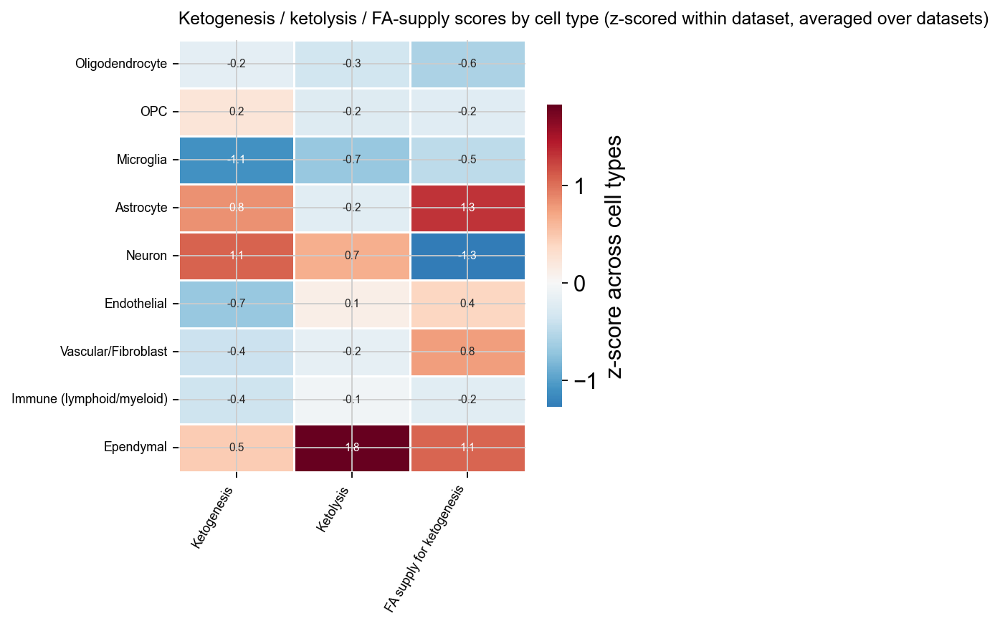

<Axes: title={'left': 'Ketogenesis / ketolysis / FA-supply scores by cell type (z-scored within dataset, averaged over datasets)'}>

In [7]:
def avg_detection(datasets, title):
    sub = DET[DET.dataset.isin(datasets) & DET.cell_type.isin(CTS_TEST)]
    if not len(sub):
        return None
    m = sub.groupby("cell_type")[[g for g in CORE if g in sub.columns]].mean().reindex([c for c in CTS_TEST if c in sub.cell_type.unique()])
    heat(m, title, "mean fraction of cells detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(m.index))
    return m
mouse_sc = [k for k, v in INFO.items() if v["species"] == "mouse" and v["modality"] == "scRNA"]
mouse_sn = [k for k, v in INFO.items() if v["species"] == "mouse" and v["modality"] == "snRNA"]
human_sn = [k for k, v in INFO.items() if v["species"] == "human" and v["modality"] == "snRNA"]
WHO = {}
WHO["mouse whole cells"] = avg_detection(mouse_sc, f"Mouse whole-cell datasets ({len(mouse_sc)}): fraction of cells detecting each ketone gene, by cell type")
WHO["mouse nuclei"] = avg_detection(mouse_sn, f"Mouse nucleus datasets ({len(mouse_sn)}): fraction of nuclei detecting each ketone gene, by cell type")
WHO["human nuclei"] = avg_detection(human_sn, f"Human nucleus datasets ({len(human_sn)}): fraction of nuclei detecting each ketone gene, by cell type")
if len(CODET):
    c = CODET[CODET.cell_type.isin(CTS_TEST)].groupby("cell_type")[["Oxct1+", "Bdh1+", "both", "both_expected_if_independent"]].mean().reindex([c for c in CTS_TEST if c in CODET.cell_type.unique()])
    print("complete ketolytic machinery (Oxct1 and Bdh1 in the same cell), mean over datasets:"); display(c.round(3))
    per = CODET.pivot_table(index="dataset", columns="cell_type", values="both")[[c for c in CTS_TEST if c in CODET.cell_type.unique()]]
    heat(per, "Fraction of cells co-detecting Oxct1 and Bdh1, per dataset and cell type", "fraction with both", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None)
s = SCORE_CT[SCORE_CT.cell_type.isin(CTS_TEST)]
z = []
for dsn in s.dataset.unique():
    b = s[s.dataset == dsn].set_index("cell_type").drop(columns="dataset"); z.append((b - b.mean()) / b.std(ddof=0))
z = pd.concat(z).groupby(level=0).mean().reindex([c for c in CTS_TEST if c in s.cell_type.unique()])
heat(z, "Ketogenesis / ketolysis / FA-supply scores by cell type (z-scored within dataset, averaged over datasets)", "z-score across cell types", fmt=".1f", cmap="RdBu_r", center=0, row_labels=list(z.index))

## 6. Disease, age and demyelination effects on the ketone genes, per cell type

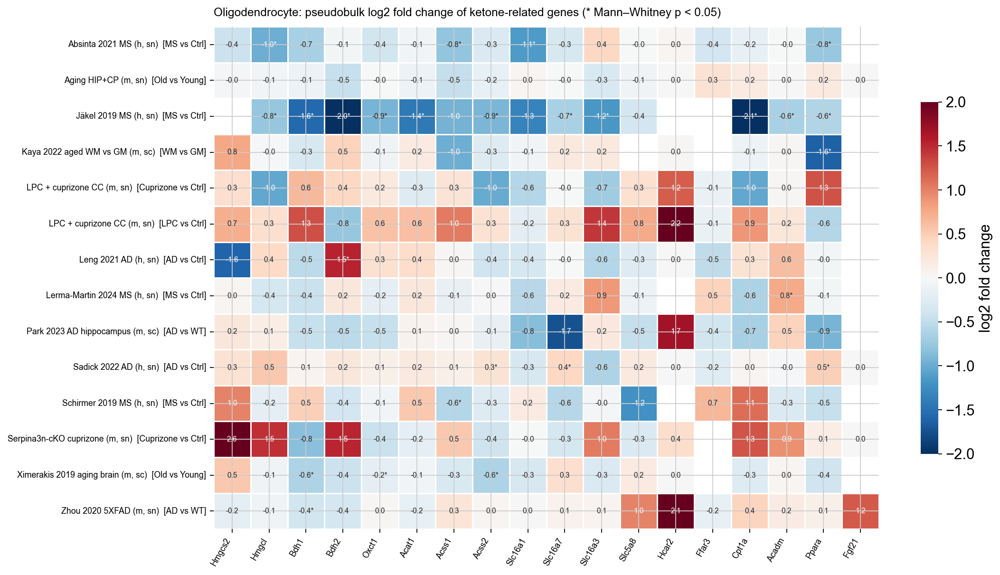

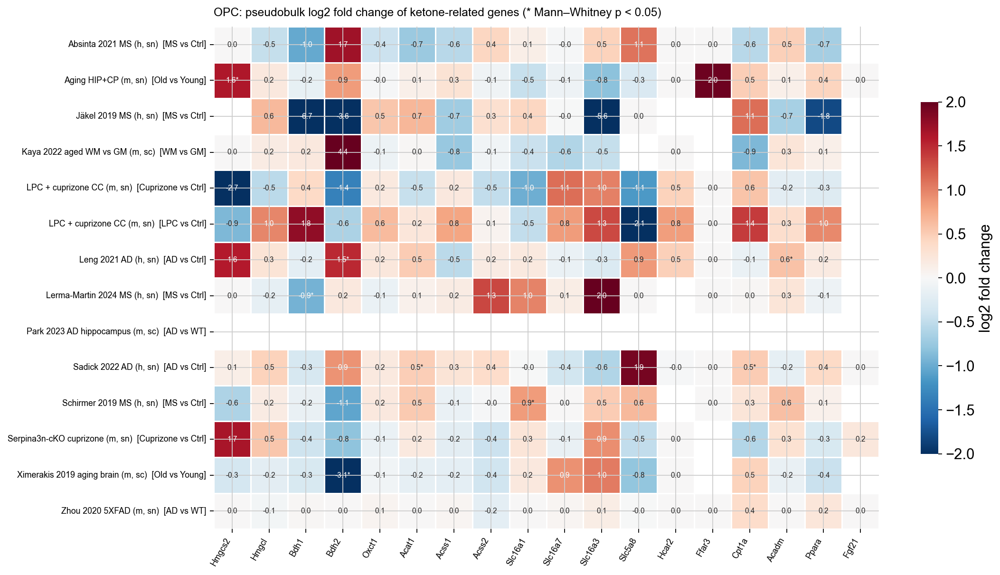

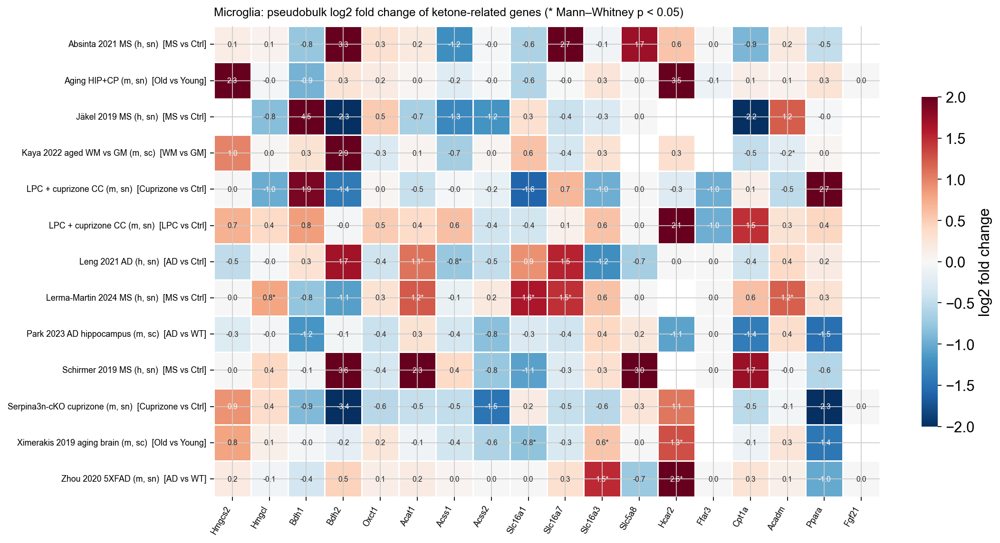

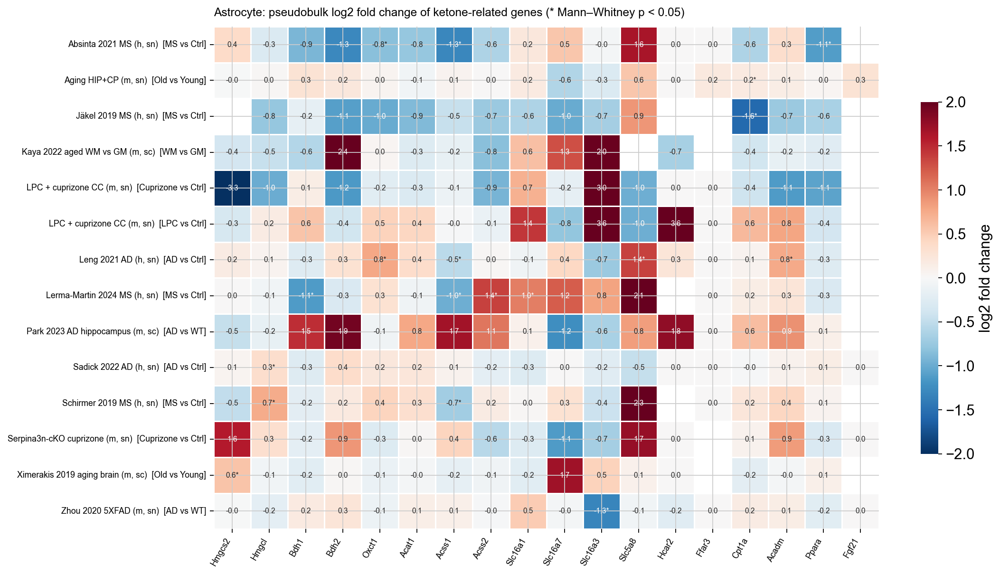

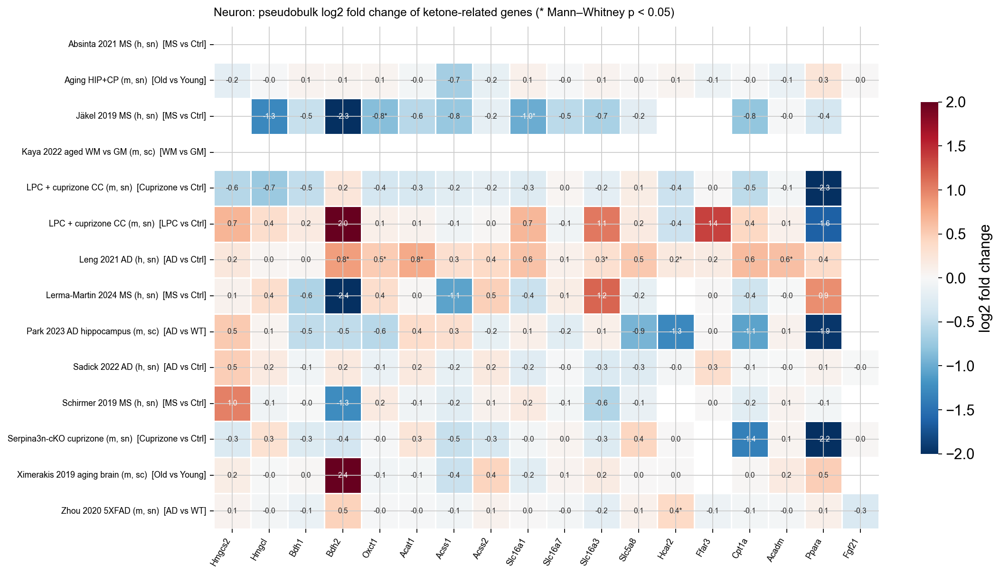

...

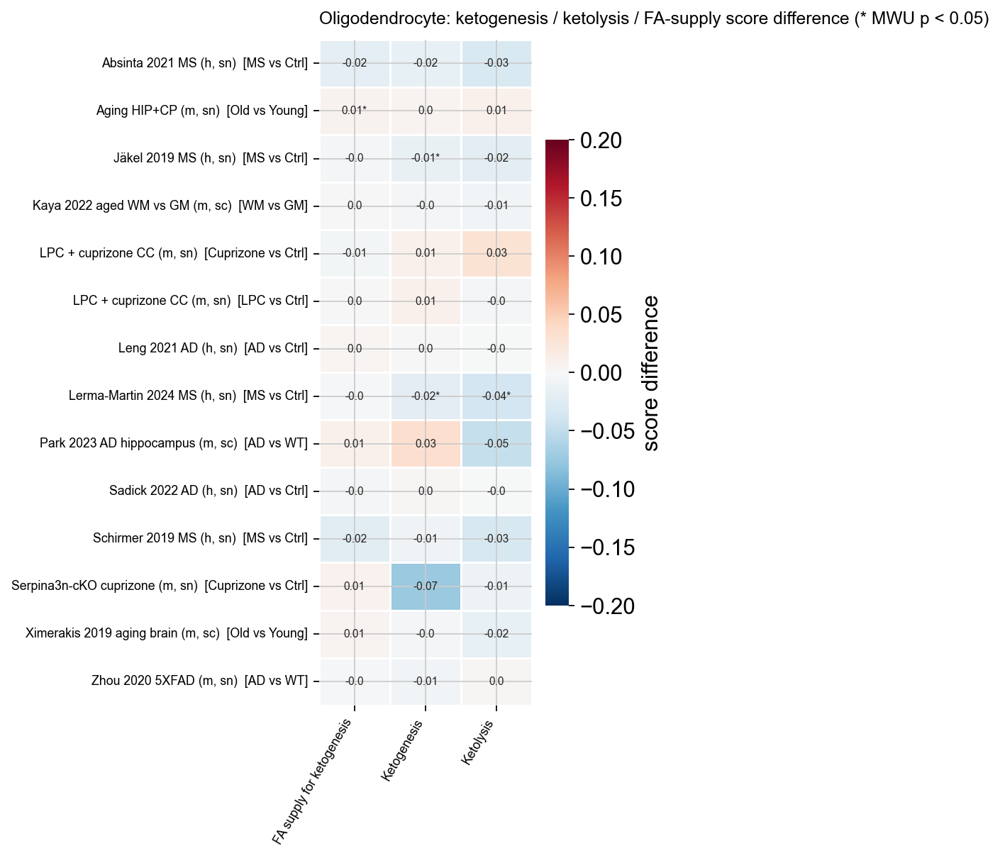

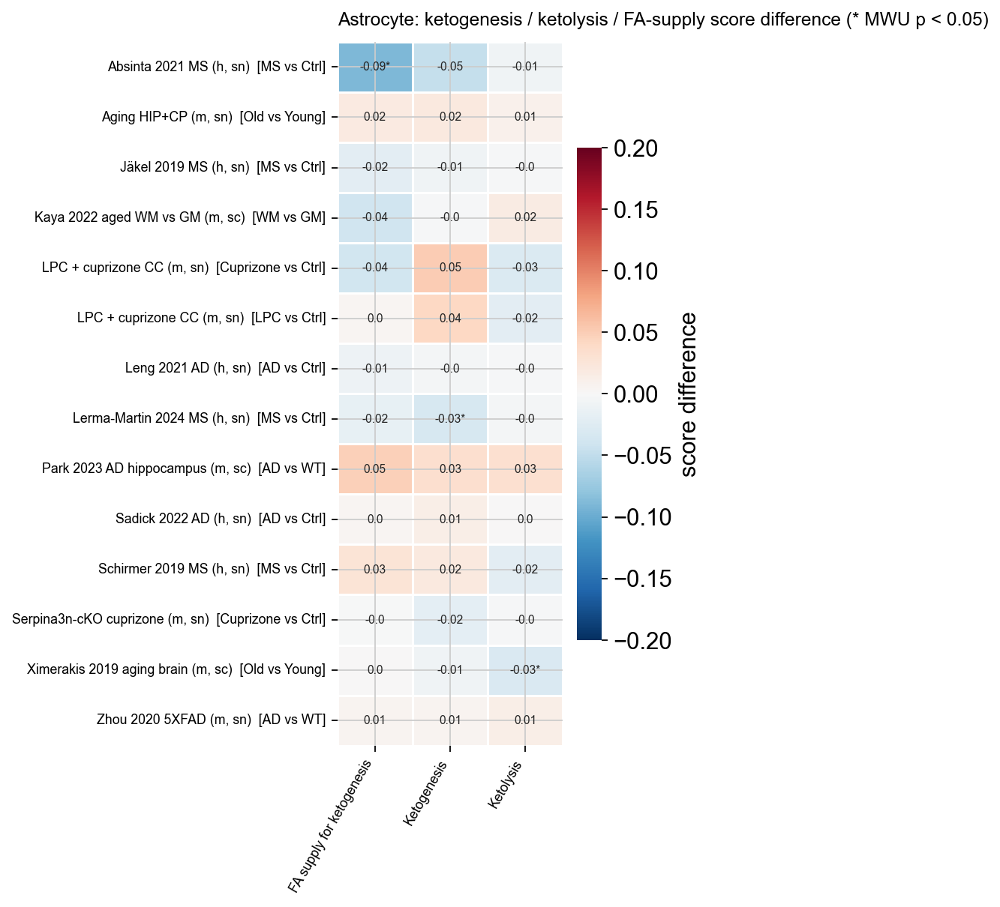

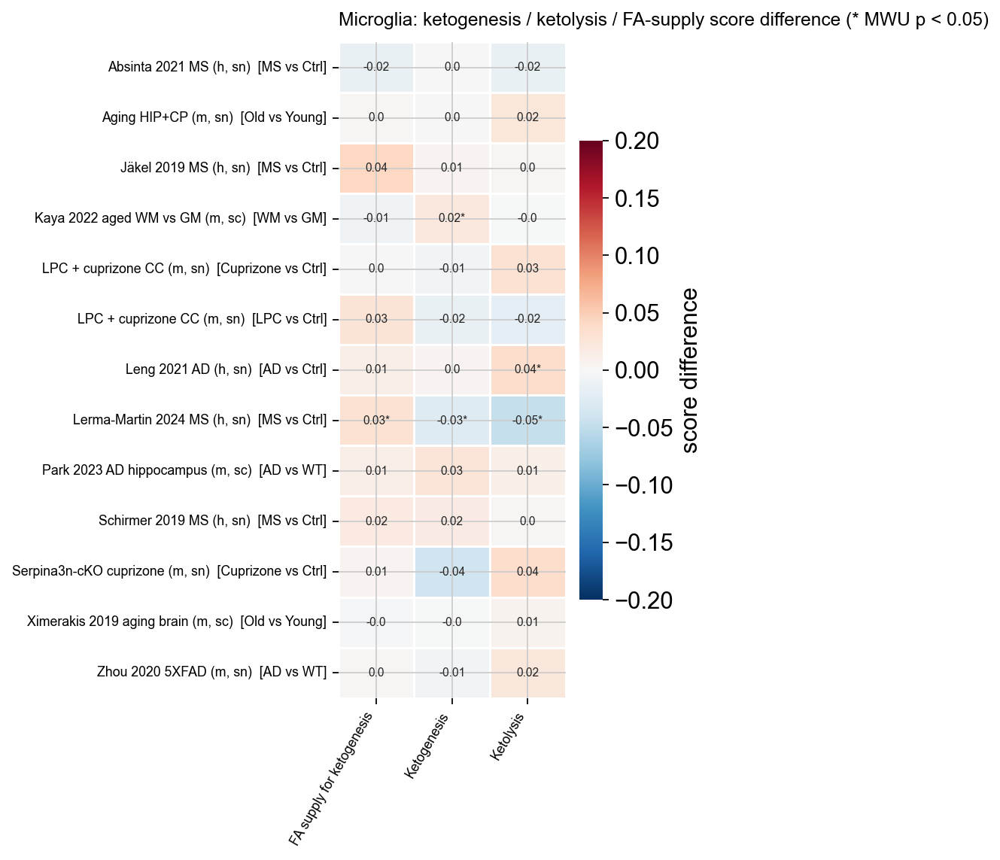

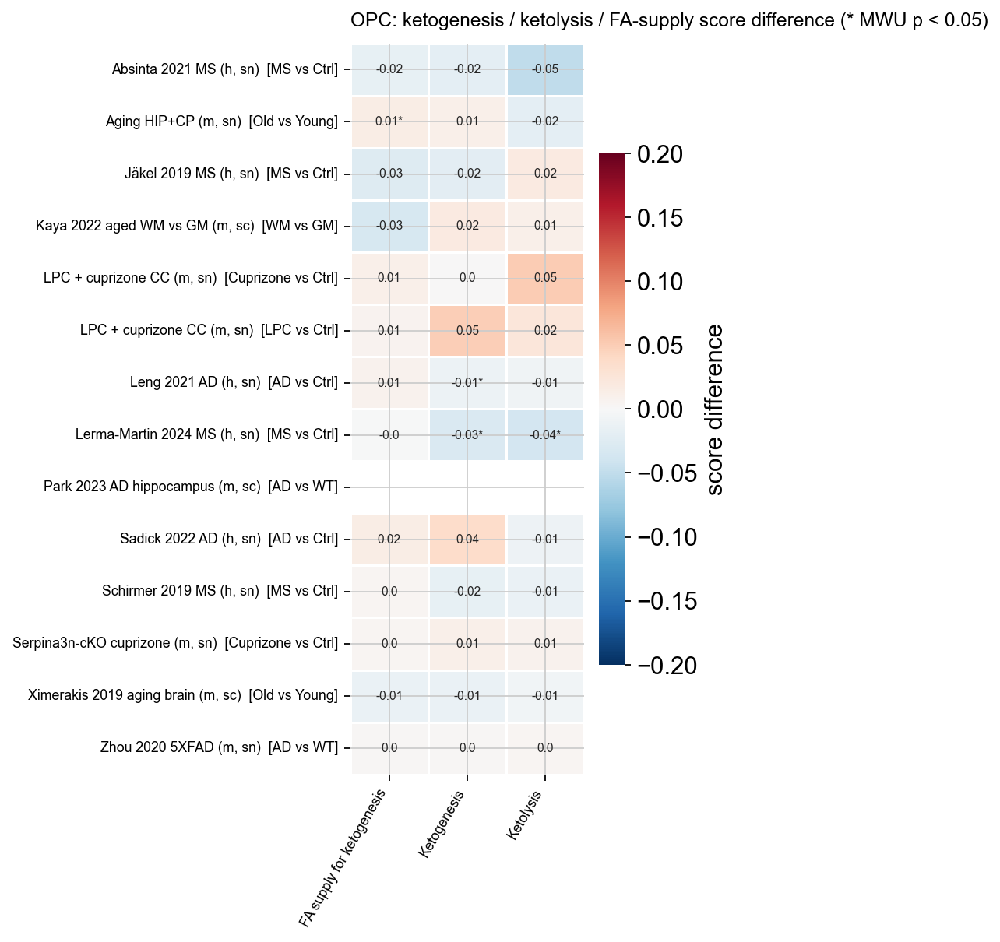

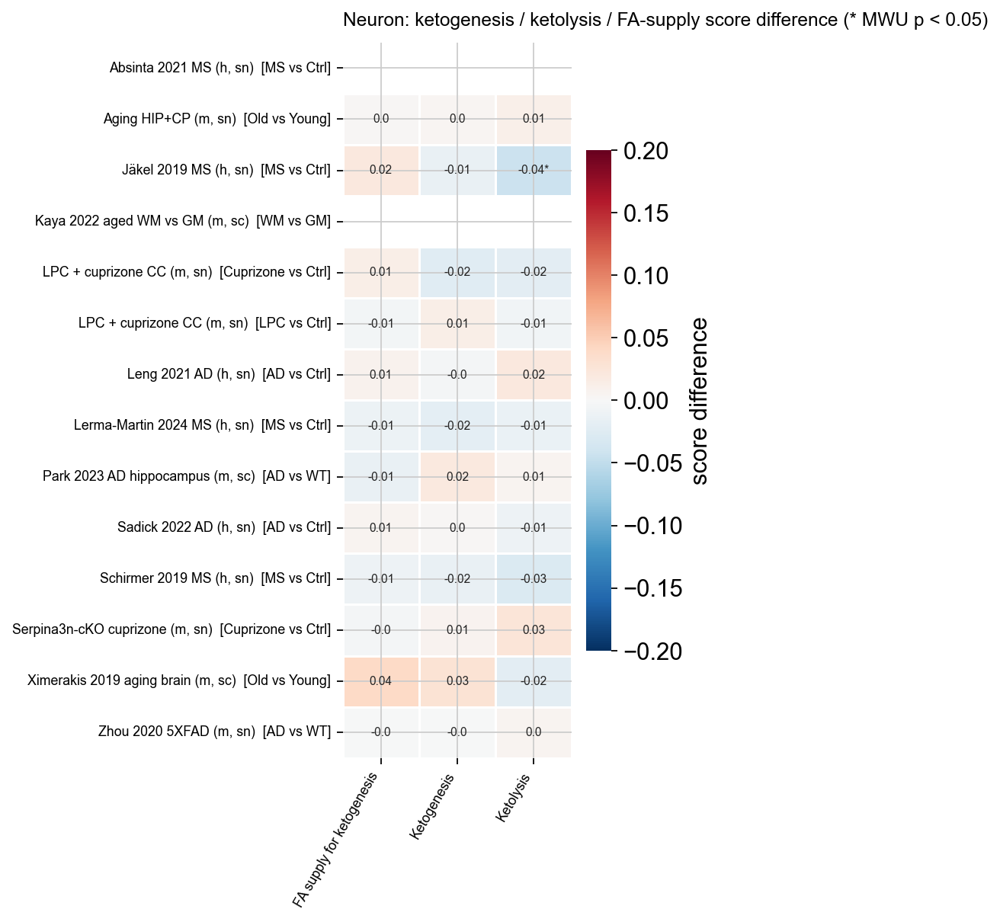

consistency of direction across contrasts (|log2FC| > 0.5), all cell types:


cell_type,Astrocyte,Endothelial,Ependymal,Immune (lymphoid/myeloid),Microglia,Neuron,OPC,Oligodendrocyte,Vascular/Fibroblast
gene,,,,,,,,,
Hmgcs2,1,-2,-1,1,4,2,0,4,0
Hmgcl,-1,0,0,-1,-1,-2,2,-1,-3
Hmgcll1,3,0,-1,3,4,-1,3,1,3
Bdh1,-1,2,-1,-5,-2,-2,-2,-3,-1
Bdh2,0,1,-2,3,0,-1,-1,-1,2
Oxct1,-1,-2,-1,0,1,-1,2,0,-3
Acat1,-1,0,1,-2,2,0,2,1,1
Acss1,-3,-1,-1,-2,-3,-3,-3,-2,2
Acss2,-3,-2,0,-1,-5,0,1,-3,-4


median log2FC across contrasts:


cell_type,Astrocyte,Endothelial,Ependymal,Immune (lymphoid/myeloid),Microglia,Neuron,OPC,Oligodendrocyte,Vascular/Fibroblast
gene,,,,,,,,,
Hmgcs2,-0.01,0.00,-0.11,0.00,0.16,0.15,0.00,0.31,0.00
Hmgcl,-0.07,0.06,-0.27,-0.05,0.02,0.02,0.16,-0.08,-0.15
Hmgcll1,0.15,0.08,-0.22,0.98,0.80,0.06,0.20,-0.17,0.40
Bdh1,-0.20,0.13,-0.17,-0.63,-0.05,-0.10,-0.20,-0.41,-0.04
Bdh2,0.21,0.10,-0.42,1.35,-0.04,0.13,0.00,-0.21,0.06
Oxct1,-0.03,-0.20,0.10,0.04,0.13,-0.02,0.05,-0.08,-0.09
Acat1,-0.00,-0.02,0.06,-0.07,0.16,0.00,0.12,-0.00,-0.00
Acss1,-0.14,-0.30,-0.19,0.02,-0.35,-0.23,-0.14,-0.06,0.36
Acss2,-0.11,-0.29,0.19,-0.09,-0.39,0.05,-0.02,-0.25,-0.49


In [8]:
DE["contrast"] = DE["dataset"].map(short) + "  [" + DE["alt"] + " vs " + DE["ref"] + "]"
DE_S["contrast"] = DE_S["dataset"].map(short) + "  [" + DE_S["alt"] + " vs " + DE_S["ref"] + "]"
def pv(df, index, columns, values):
    return df.drop_duplicates([index, columns]).set_index([index, columns])[values].unstack(columns)
for ct in [c for c in CTS_TEST + ["spot"] if c in DE.cell_type.unique()]:
    sub = DE[DE.cell_type == ct]
    d = pv(sub, "contrast", "gene", "log2FC"); d = d[[g for g in CORE if g in d.columns]]
    p = pv(sub, "contrast", "gene", "MWU_p").reindex(index=d.index, columns=d.columns)
    heat(d, f"{ct}: pseudobulk log2 fold change of ketone-related genes (* Mann–Whitney p < 0.05)", "log2 fold change", fmt=".1f", cmap="RdBu_r", center=0, vmin=-2, vmax=2,
         annot=(d.round(1).astype(str).replace("nan", "") + np.where(p.values < 0.05, "*", "")).values, row_labels=list(d.index))
for ct in ["Oligodendrocyte", "Astrocyte", "Microglia", "OPC", "Neuron"]:
    sub = DE_S[DE_S.cell_type == ct]
    if not len(sub):
        continue
    d = pv(sub, "contrast", "score", "diff"); p = pv(sub, "contrast", "score", "MWU_p").reindex(index=d.index, columns=d.columns)
    heat(d, f"{ct}: ketogenesis / ketolysis / FA-supply score difference (* MWU p < 0.05)", "score difference", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2,
         annot=(d.round(2).astype(str).replace("nan", "") + np.where(p.values < 0.05, "*", "")).values, row_labels=list(d.index))
# consistency per cell type
cons_rows = []
for ct in [c for c in CTS_TEST if c in DE.cell_type.unique()]:
    sub = DE[DE.cell_type == ct]
    for g, gg in sub.groupby("gene"):
        cons_rows.append({"cell_type": ct, "gene": g, "n_contrasts": len(gg), "n_up": int((gg.log2FC > 0.5).sum()), "n_down": int((gg.log2FC < -0.5).sum()),
                          "median_log2FC": gg.log2FC.median(), "n_sig_up": int(((gg.MWU_p < 0.05) & (gg.log2FC > 0)).sum()), "n_sig_down": int(((gg.MWU_p < 0.05) & (gg.log2FC < 0)).sum())})
CONS = pd.DataFrame(cons_rows); CONS["net"] = CONS.n_up - CONS.n_down
print("consistency of direction across contrasts (|log2FC| > 0.5), all cell types:")
display(CONS.pivot(index="gene", columns="cell_type", values="net").reindex([g for g in KG if g in CONS.gene.unique()]).fillna(0).astype(int))
print("median log2FC across contrasts:"); display(CONS.pivot(index="gene", columns="cell_type", values="median_log2FC").reindex([g for g in KG if g in CONS.gene.unique()]).round(2))

## 7. Astrocyte ketogenesis: is *Hmgcs2* coupled to fatty-acid oxidation and PPARα?

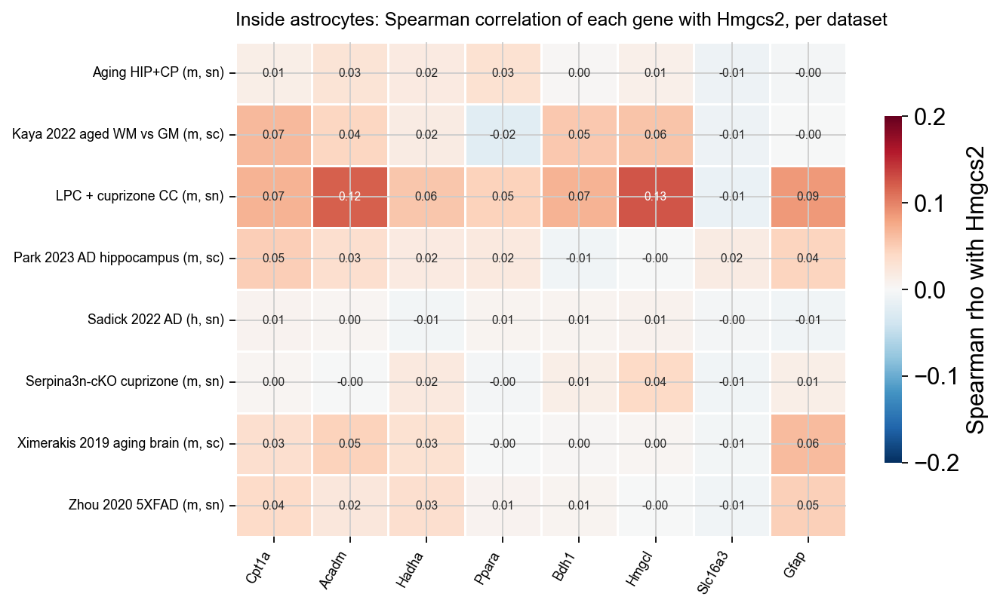

detection enrichment in Hmgcs2+ vs Hmgcs2- astrocytes:


gene,Cpt1a,Acadm,Hadha,Ppara,Bdh1,Hmgcl,Slc16a3,Gfap
Aging_snRNA_HIP_CP_mouse,1.15,1.35,1.17,1.22,1.04,1.14,0.34,0.99
Kaya2022_aged_WM_vs_GM_scRNA,1.92,1.54,1.14,0.41,1.74,1.93,0.00,1.04
LPC_Cuprizone_CC_snRNA_mouse,2.01,3.44,1.75,1.59,2.18,3.79,0.00,1.39
Park2023_AD_hippocampus_scRNA,2.50,1.63,1.47,2.19,0.91,1.01,2.63,1.75
Sadick2022_AD_human_astro_oligo_snRNA,1.34,1.19,0.94,1.17,1.40,1.60,0.61,1.00
Serpina3n_Cuprizone_snRNA_mouse,1.08,1.03,1.35,0.96,1.33,1.98,0.00,1.38
Ximerakis2019_aging_brain_scRNA,1.47,1.55,1.39,0.98,1.05,1.08,0.00,1.64
Zhou2020_5XFAD_snRNA,2.03,1.73,1.75,1.23,1.14,0.98,0.00,1.96


astrocytes: fraction detecting the ketogenic / FA-oxidation genes per dataset:


,n_cells,Hmgcs2,Hmgcl,Bdh1,Oxct1,Cpt1a,Acadm,Ppara,Slc16a3,Fgf21
dataset,,,,,,,,,,
Absinta2021_MS_human_snRNA,8211,0.000,0.053,0.057,0.098,0.095,0.081,0.168,0.019,NaN
Aging_snRNA_HIP_CP_mouse,12690,0.048,0.176,0.228,0.661,0.257,0.150,0.347,0.005,0.0
Jakel2019_MS_human_snRNA,1242,NaN,0.038,0.041,0.048,0.012,0.071,0.076,0.015,NaN
Kaya2022_aged_WM_vs_GM_scRNA,1933,0.028,0.138,0.207,0.401,0.188,0.293,0.044,0.004,NaN
LPC_Cuprizone_CC_snRNA_mouse,835,0.048,0.060,0.109,0.358,0.117,0.073,0.162,0.004,NaN
Leng2021_AD_human_snRNA,11901,0.001,0.046,0.058,0.059,0.114,0.060,0.122,0.019,NaN
LermaMartin2024_MS_human_snRNA,13985,0.000,0.108,0.086,0.251,0.284,0.169,0.353,0.035,NaN
Park2023_AD_hippocampus_scRNA,7470,0.021,0.056,0.097,0.182,0.052,0.144,0.015,0.005,NaN
Sadick2022_AD_human_astro_oligo_snRNA,47240,0.001,0.213,0.229,0.236,0.466,0.316,0.533,0.058,0.0


In [9]:
if ASTRO:
    R = pd.DataFrame({k: v["spearman_rho"] for k, v in ASTRO.items()}).T
    heat(R, "Inside astrocytes: Spearman correlation of each gene with Hmgcs2, per dataset", "Spearman rho with Hmgcs2", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2)
    E = pd.DataFrame({k: v["enrichment(+/-)"] for k, v in ASTRO.items()}).T
    print("detection enrichment in Hmgcs2+ vs Hmgcs2- astrocytes:"); display(E.round(2))
    frac = DET[DET.cell_type == "Astrocyte"].set_index("dataset")[["n_cells"] + [g for g in ["Hmgcs2", "Hmgcl", "Bdh1", "Oxct1", "Cpt1a", "Acadm", "Ppara", "Slc16a3", "Fgf21"] if g in DET.columns]]
    print("astrocytes: fraction detecting the ketogenic / FA-oxidation genes per dataset:"); display(frac.round(3))

## 8. Ketone genes and the *C4b*⁺ oligodendrocyte state (mouse datasets)

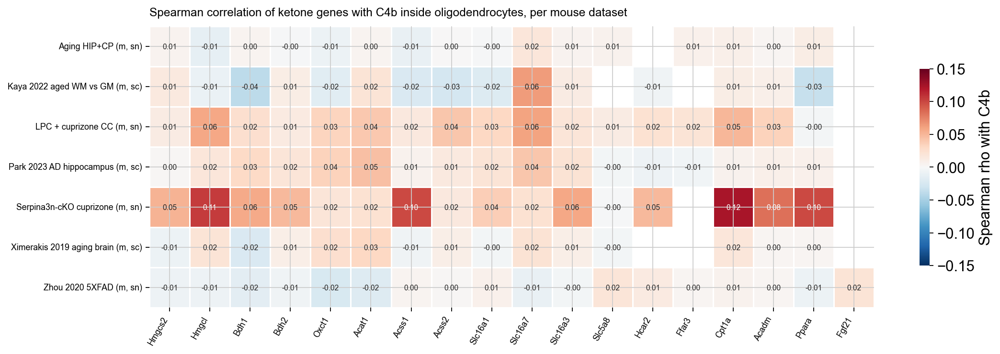

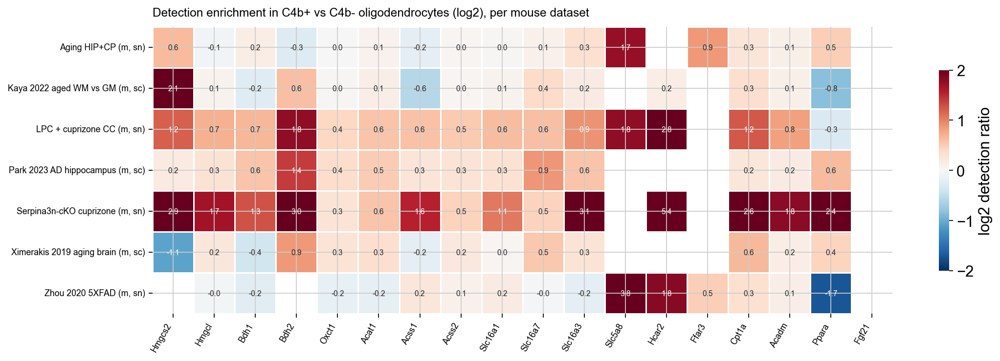

In [10]:
if CO:
    R = pd.DataFrame({k: v["spearman_rho"] for k, v in CO.items()}).T; R = R[[g for g in CORE if g in R.columns]]
    heat(R, "Spearman correlation of ketone genes with C4b inside oligodendrocytes, per mouse dataset", "Spearman rho with C4b", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.15, vmax=0.15)
    E = pd.DataFrame({k: v["enrichment(+/-)"] for k, v in CO.items()}).T; E = E[[g for g in CORE if g in E.columns]]
    heat(np.log2(E.replace(0, np.nan)), "Detection enrichment in C4b+ vs C4b- oligodendrocytes (log2), per mouse dataset", "log2 detection ratio", fmt=".1f", cmap="RdBu_r", center=0, vmin=-2, vmax=2)

## 9. Human MS and AD by the authors' condition labels

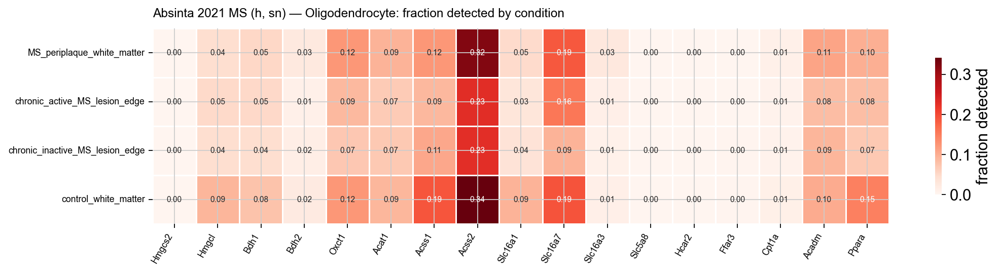

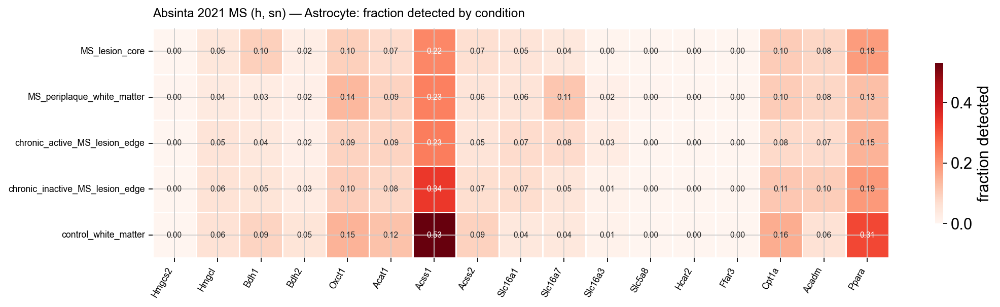

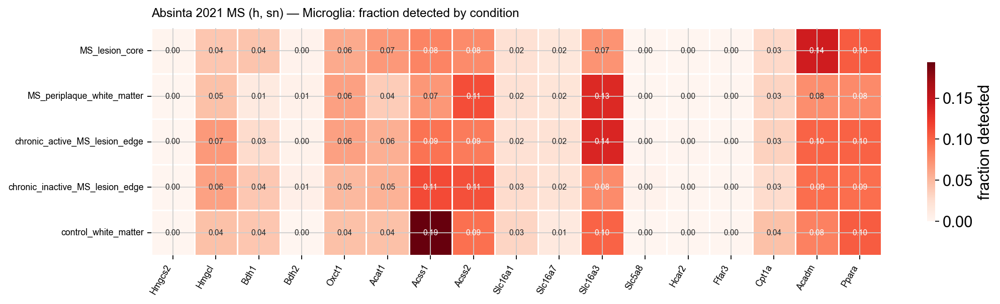

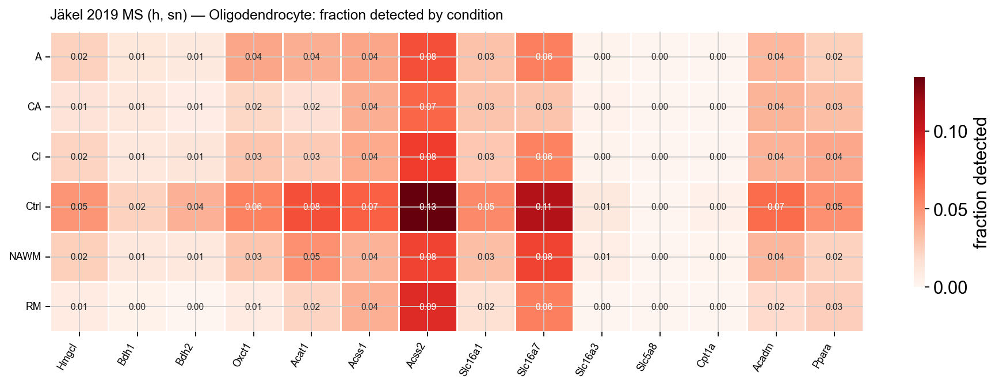

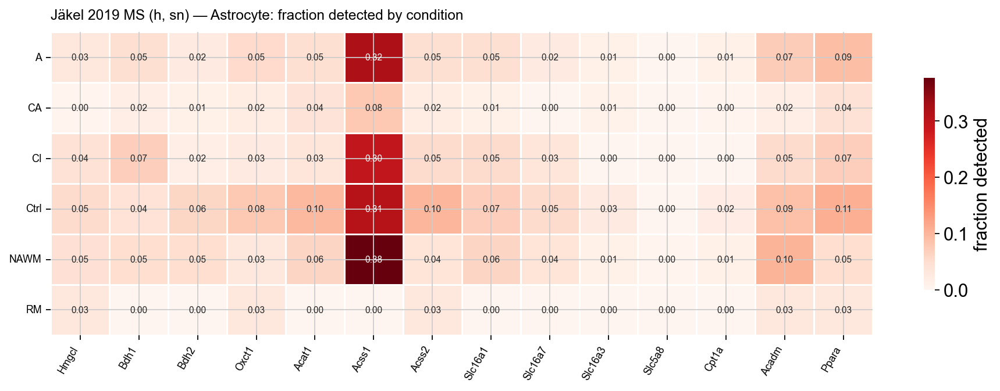

...

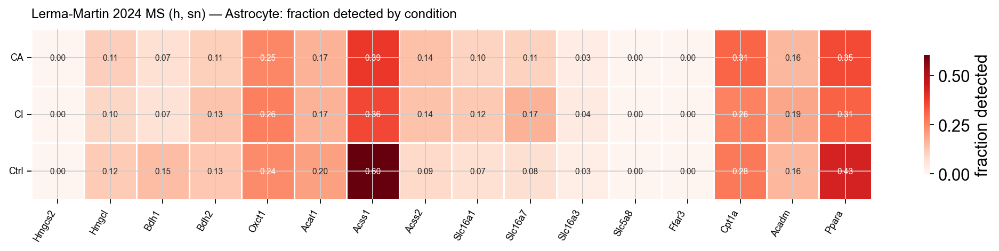

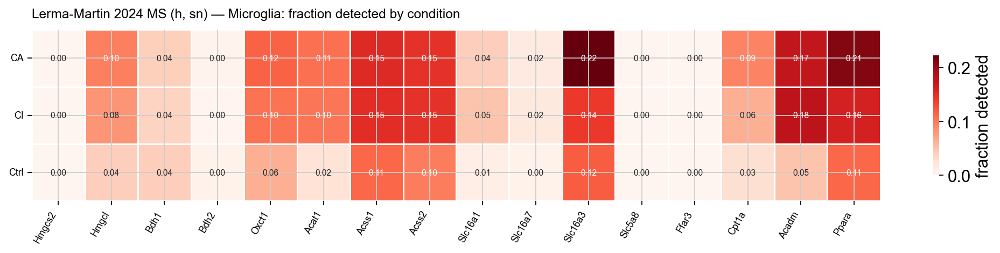

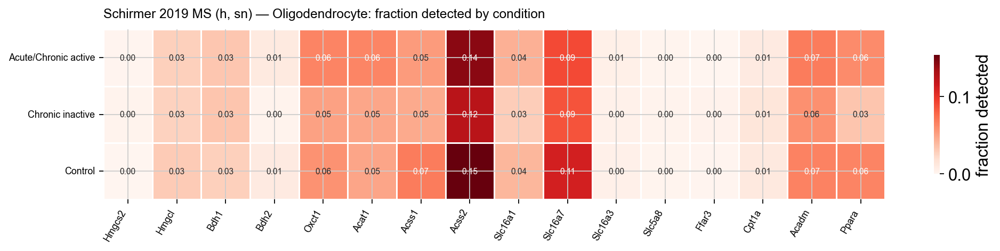

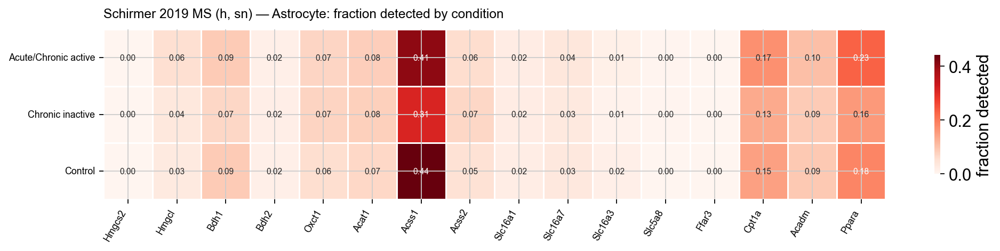

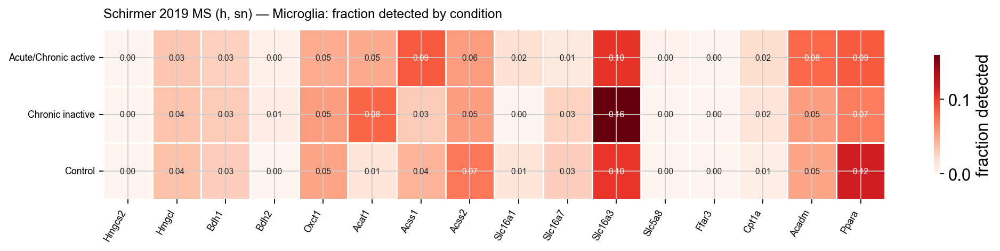

In [11]:
for (name, ct, kind), t in COND.items():
    if kind != "detection" or ct not in ("Oligodendrocyte", "Astrocyte", "Microglia"):
        continue
    gene_heat(t, f"{short(name)} — {ct}: fraction detected by condition", "fraction detected", row_labels=list(t.index))

## 10. Summary tables

In [12]:
display(pd.DataFrame(INFO).T)
DET.to_csv("../../results/ketone_public_detection_by_celltype.csv", index=False); MEAN.to_csv("../../results/ketone_public_mean_by_celltype.csv", index=False)
if len(CODET): CODET.to_csv("../../results/ketone_public_codetection_Oxct1_Bdh1.csv", index=False)
SCORE_CT.to_csv("../../results/ketone_public_scores_by_celltype.csv", index=False)
DE.to_csv("../../results/ketone_public_gene_contrasts.csv", index=False); DE_S.to_csv("../../results/ketone_public_score_contrasts.csv", index=False)
CONS.to_csv("../../results/ketone_public_gene_consistency.csv", index=False)
if ASTRO: pd.concat(ASTRO, names=["dataset", "gene"]).to_csv("../../results/ketone_public_astrocyte_Hmgcs2_coupling.csv")
if CO: pd.concat(CO, names=["dataset", "gene"]).to_csv("../../results/ketone_public_c4b_coexpression_oligodendrocytes.csv")
if COND: pd.concat({f"{k[0]}|{k[1]}|{k[2]}": v for k, v in COND.items()}, names=["dataset|cell_type|kind", "condition"]).to_csv("../../results/ketone_public_by_condition.csv")
for k, v in WHO.items():
    if v is not None:
        v.to_csv(f"../../results/ketone_who_{k.replace(' ', '_')}.csv")
print("results written")

,species,modality,n_cells,n_samples
Absinta2021_MS_human_snRNA,human,snRNA,66432,8
Aging_snRNA_HIP_CP_mouse,mouse,snRNA,109822,8
Chen2020_ST_AppNLGF_mouse,mouse,spatial,19021,20
Jakel2019_MS_human_snRNA,human,snRNA,17790,20
Kaya2022_aged_WM_vs_GM_scRNA,mouse,scRNA,29623,8
LPC_Cuprizone_CC_snRNA_mouse,mouse,snRNA,30338,8
Leng2021_AD_human_snRNA,human,snRNA,92199,20
LermaMartin2024_MS_human_Visium,human,spatial,70238,18
LermaMartin2024_MS_human_snRNA,human,snRNA,102672,16
Park2023_AD_hippocampus_scRNA,mouse,scRNA,47660,6


results written


### Interpretation

**Who makes ketone bodies.** Almost nobody in brain parenchyma at the transcript level. *Hmgcs2*, the rate-limiting ketogenic enzyme, is detected in 3 % of astrocytes in whole cells and nuclei alike, in 0 % of oligodendrocytes and microglia, and in 0 % of any human nucleus type; where it does appear it is vascular: 12–22 % of endothelial cells, 7–14 % of mural / fibroblast cells, 53 % of the sorted VLMC in Falcão, and a subset of neurons in the whole-cell datasets (15 %). *Hmgcl* is broad and *Bdh1* (which works in both directions) sits in astrocytes, OPCs, ependymal cells and neurons (16–27 %), not in oligodendrocytes (5–7 %) or microglia (1–2 %). Astrocyte ketogenesis therefore rests on a small *Hmgcs2*⁺ subset; inside astrocytes *Hmgcs2*⁺ cells are 1.5–3.8× more likely to express *Acadm*, *Cpt1a* and *Hmgcl* in the demyelination and aged-white-matter datasets, i.e. the ketogenic astrocytes are the fatty-acid-oxidising ones, but the coupling to *Ppara* is weak (ρ ≤ 0.05 everywhere).

**Who uses them.** *Oxct1* (SCOT), the committed ketolytic step, is the most widely expressed ketone gene: 65 % of neuronal, 48 % of astrocytic, 33–39 % of oligodendrocyte and 43 % of microglial nuclei / cells, 82 % of OPC / COP / NFOL in Falcão. The *complete* machinery (*Oxct1* and *Bdh1* in the same cell) is rarer and follows *Bdh1*: ependymal cells 18 %, neurons 13 %, OPCs 7 %, astrocytes 6 %, oligodendrocytes 2 %, microglia < 1 %; in sorted cells 45 % of OPC / COP / NFOL, 9 % of control MOL, 23 % of EAE MOL, 3 % of microglia. Co-detection is at the level expected from the two marginals, so there is no dedicated "ketolytic" subpopulation beyond what *Bdh1* defines. Along the oligodendrocyte lineage, ketolytic capacity is a progenitor feature that mature oligodendrocytes lose and partly regain in the disease-associated state.

**Who transports and who senses.** MCT1 (*Slc16a1*) is endothelial (42 % of whole cells) and oligodendroglial (34 %), MCT2 (*Slc16a7*) neuronal (50 % of nuclei), MCT4 (*Slc16a3*) microglial and, in EAE, astrocytic (84 % of DA astrocytes in situ), SMCT1 (*Slc5a8*) essentially absent. *Hcar2* is a myeloid receptor everywhere (6–9 % of microglia / immune cells in whole cells, 8 % of microglia and 21 % of proliferating microglia in EAE in situ, 59 % of sorted microglia in Falcão), *Ffar3* is not detected in brain, *Ffar2* barely.

**Disease.** The ketone genes move modestly and in a reproducible direction. Across the public contrasts, *Bdh1* falls in oligodendrocytes (down in 3 more contrasts than up; median log2FC −0.41; Jäkel MS −1.6, Ximerakis aging −0.6) and in immune cells, *Acss1* / *Acss2* fall in most cell types, *Ppara* falls in oligodendrocytes, microglia and astrocytes, MCT1 falls in oligodendrocytes (−0.34) but rises in astrocytes and immune cells, and *Hcar2* rises in microglia (median +0.8 log2; +1.3 in aged brain, +2.6 in 5XFAD) and immune cells. The ketogenesis and ketolysis *scores* are slightly lower in MS oligodendrocytes, OPCs, microglia and astrocytes in Lerma-Martin 2024 (−0.02 to −0.05, all p < 0.05), in Jäkel oligodendrocytes and in Leng Braak-6 OPCs; nothing rises. In EAE in situ the tissue-wide changes are *Acss2* down (13 cell types), *Ppargc1a* down (10), *Ppara* down (6), MCT1 up (12) and MCT4 up (13), *Hcar2* "up" in 15 cell types (spill-over from myeloid cells, which are the only cells that express it in sorted data), and *Bdh1* up in homeostatic and DA oligodendrocytes (+0.2 log2) but down in microglia, endothelial and fibroblast populations.

**The disease-associated oligodendrocyte.** In sorted EAE MOL versus control MOL, *Bdh1* (2.3×), *Hmgcll1* (2.3×), *Acat1* (1.2×), *Cpt1a* (2.5×), *Cpt2*, *Hadha* and MCT4 rise while MCT1 (−0.24 log2) and *Acss2* fall; *Oxct1* and *Hmgcs2* do not change. In situ the picture is subtler: EAE raises *Bdh1* in both homeostatic and DA oligodendrocytes, but within the same sample DA oligodendrocytes have *less* *Bdh1*, *Acss2*, *Cpt2*, *Ppara* and *Ppargc1a* than homeostatic ones and more MCT4 and *Hcar2* (the latter myeloid spill-over). So the DA state is not a ketogenic or strongly ketolytic state; it is a fatty-acid-importing, lactate-exporting (MCT4 up, MCT1 down) state in which *Bdh1* is the one ketone enzyme that is induced by the disease environment. In white-matter-rich Visium spots *Bdh1* rises with age (r = 0.86, p = 0.03) alongside *Slc16a3*, *Hcar2* and *Bsg*.

**The *C4b* axis.** No ketone gene correlates with *C4b* inside oligodendrocytes beyond |ρ| ≈ 0.1 in any dataset. The detection enrichments in *C4b*⁺ cells that do appear, *Hcar2* (7–43×), *Hmgcs2* (2–7×) and *Cpt1a* (2–6×) in the LPC / cuprizone and *Serpina3n*-cKO nuclei, are the microglial ambient-RNA signature of demyelinating-lesion nuclei documented in OligoC4b, and *Bdh1* is ~2× enriched in *C4b*⁺ sorted MOL and in *C4b*⁺ oligodendrocyte nuclei after LPC / cuprizone. Ketone bodies are therefore not part of the *C4b*⁺ program; what the program shares with the ketone arm is the fatty-acid-oxidation entry (*Cpt1a*, *Hadha*) and the lactate / ketone exporter MCT4.

**Caveats.** *Hmgcs2*, *Hcar2*, *Ffar3*, *Slc5a8* and *Fgf21* are near the detection floor in most datasets, so their fold changes are unstable and nuclei under-detect them further; the EAE 5K panel lacks *Hmgcs2*, *Hmgcl*, *Oxct1*, *Acat1* and MCT2, so ketogenesis / ketolysis scores cannot be computed there; in situ *Hcar2* inside non-myeloid segments is spill-over; and transcript abundance says nothing about BHB flux, which in brain is dominated by import from the circulation rather than local synthesis.